In [19]:

import xarray as xr
import matplotlib.pyplot as plt
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as crs
import cartopy.feature as cfeature
import netCDF4 as nc
import rioxarray as rxr
import numpy as np
import rasterio

In [2]:
# Load the dataset
msa_file = '../gis/msa/msaUS_mland_aea1_M1.shp'
msa_gdf_crsaea = gpd.read_file(msa_file)
msa_gdf_crs4326 = msa_gdf_crsaea.to_crs(epsg=4326)

In [20]:
from utils import get_masked_raster

### NDVI

#### NDVI exploration

In [3]:

ds = nc.Dataset('../gis/NDVI/AVHRR-Land_v005_AVH13C1_NOAA-07_19810624_c20170610041337.nc')
# data = ds['NDVI'][:]


In [51]:
ds

<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    title: Normalized Difference Vegetation Index parameters derived from NOAA-07 GAC data for day 1981/175
    institution: NASA/GSFC/SED/ESD/HBSL/TIS/MODIS-LAND > MODIS Land Science Team, Terrestrial Information Systems,  Hydrospheric and Biospheric Science Laboratory, Earth Sciences Division, Science and Exploration Directorate, Goddard Space Flight Center, NASA
    Conventions: CF-1.6, ACDD-1.3
    standard_name_vocabulary: CF Standard Name Table (v25, 05 July 2013)
    naming_authority: gov.noaa.ncei
    license: See the Use Agreement for this CDR available from the NOAA CDR webpage
    cdm_data_type: Grid
    time_coverage_start: 1981-06-24T00:00:00Z
    time_coverage_end: 1981-06-24T23:59:59Z
    product_version: v5r0
    platform: NOAA-4 > National Oceanic & Atmospheric Administration-4
    sensor: AVHRR > Advanced Very High Resolution Radiometer
    keywords_vocabulary: NASA Global Change Master Direc

In [37]:
ds.spatial_resolution

'0.050000 degrees per pixel'

In [ ]:
from affine import Affine
resolution = 0.05
# ndvi_transform_world = Affine(resolution, 0.0, ds.geospatial_lon_min, 0.0, -resolution, ds.geospatial_lat_max)

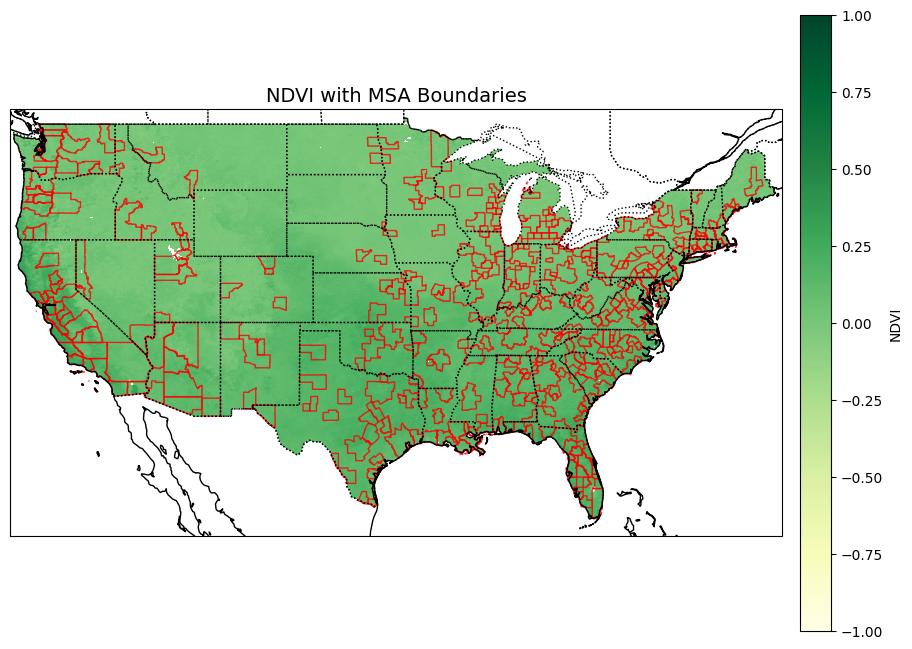

In [7]:
# View the NDVI and MSA data

ndvi_file = '../gis/NDVI/masked_us_ndvi_1982_2021.nc'
ndvi_ds = xr.open_dataset(ndvi_file)
year_month = '1982-01'
ndvi_year = ndvi_ds.sel(time=year_month)['NDVI_masked']

# Extract coordinates
lon = ndvi_ds['lon'].values
lat = ndvi_ds['lat'].values

import cartopy.crs as ccrs
# Create the plot
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot NDVI data
ndvi_plot = ax.pcolormesh(lon, lat, ndvi_year, cmap='YlGn', vmin=-1, vmax=1, shading='auto')

# Add colorbar
cbar = plt.colorbar(ndvi_plot, ax=ax, orientation='vertical', pad=0.02, label='NDVI')

# Plot MSA boundaries
msa_gdf_crs4326.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=1, alpha=0.8)

# Add map features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linestyle=':')

ax.set_title('NDVI with MSA Boundaries', fontsize=14)
plt.show()

#### calculate clipped NDVI transform

In [93]:
ndvi_ds.dims

FrozenMappingWarningOnValuesAccess({'lat': 516, 'lon': 1170, 'time': 480})

In [8]:
# recalulate the ndvi transform
ndvi_ds.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
print(ndvi_ds.rio.bounds())

from affine import Affine

lon_min, lat_min, lon_max, lat_max = ndvi_ds.rio.bounds()

resolution_x = resolution_y = 0.05

# Construct the affine transform
ndvi_transform = Affine(resolution_x, 0.0, lon_min, 0.0, -resolution_y, lat_max)
print(ndvi_transform)

# another way to calculate the transform
import rasterio
ndvi_transform = rasterio.transform.from_origin(lon_min, lat_max, resolution_x, resolution_y)
print(ndvi_transform)


(-124.99999847607903, 24.100000003703588, -66.49999389452644, 49.89999618159914)
| 0.05, 0.00,-125.00|
| 0.00,-0.05, 49.90|
| 0.00, 0.00, 1.00|
| 0.05, 0.00,-125.00|
| 0.00,-0.05, 49.90|
| 0.00, 0.00, 1.00|


#### NDVI change for a specific MSA

In [9]:
ndvi_file = '../gis/NDVI/masked_us_ndvi_1982_2021.nc'
ndvi_ds = xr.open_dataset(ndvi_file)


In [ ]:
year_month = '2010-07'
ndvi_ym_raster = ndvi_ds.sel(time=year_month)['NDVI_masked'].values
# plt.imshow(ndvi_ym_raster)
# plt.imshow(ndvi_ds['NDVI_masked'][:,:,0])

#### NDVI change plot

urban greening change:

    decrease:
        'Washington-Arlington-Alexandria, DC-VA-MD-WV Metro Area'
        'Pittsburgh, PA Metro Area'
        'New Orleans-Metairie, LA Metro Area'

    increase:
        'Seattle-Tacoma-Bellevue, WA Metro Area'
        'Los Angeles-Long Beach-Anaheim, CA Metro Area'
        'Atlanta-Sandy Springs-Roswell, GA Metro Area'

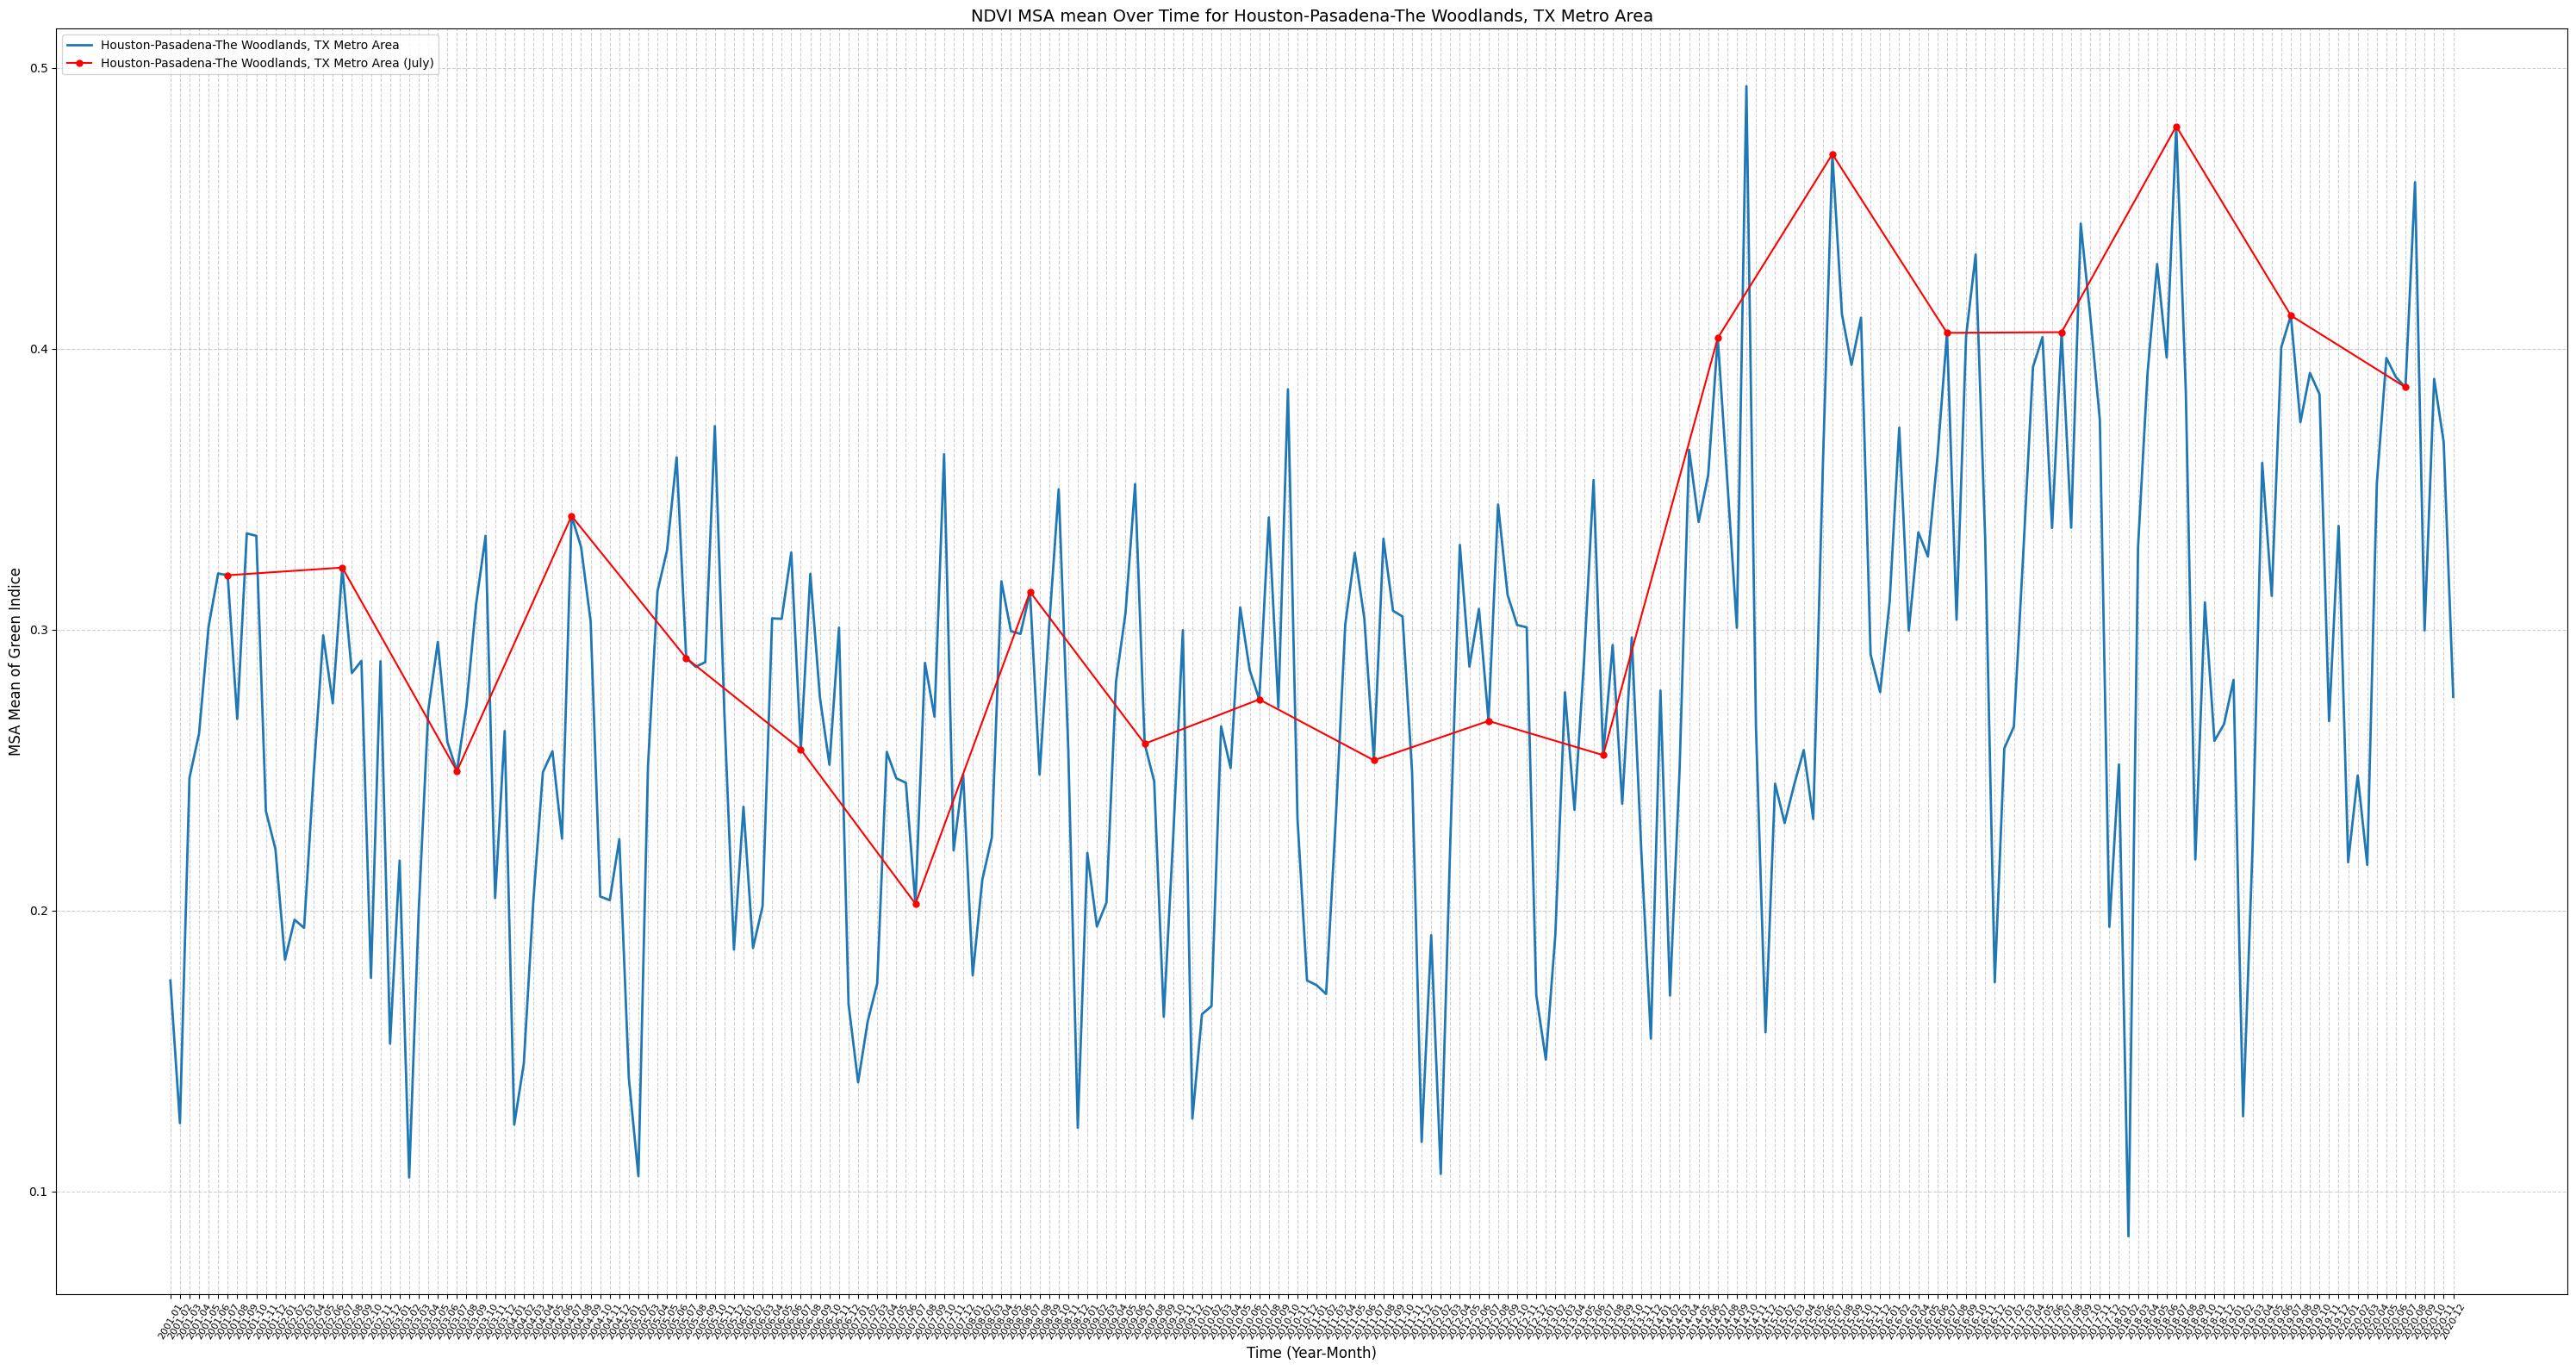

In [11]:
selected_MSA_list = [
    # 'Washington-Arlington-Alexandria, DC-VA-MD-WV Metro Area',
    # 'Pittsburgh, PA Metro Area',
    # 'New Orleans-Metairie, LA Metro Area',
    # 'Seattle-Tacoma-Bellevue, WA Metro Area',
    # 'Los Angeles-Long Beach-Anaheim, CA Metro Area',
    # 'Atlanta-Sandy Springs-Roswell, GA Metro Area',
    'Houston-Pasadena-The Woodlands, TX Metro Area',
    ]


import matplotlib.pyplot as plt

# calculate and Plot the NDVI MSA mean for the selected MSAs over time

# Create the figure before the loop


for msa_name in selected_MSA_list:
    selected_msa = msa_gdf_crs4326[msa_gdf_crs4326['NAMELSAD'] == msa_name]
    time_series = []
    indice_mean_list = []
    july_time_series = []
    july_mean_list = []

    plt.figure(figsize=(30, 16))

    for year in range(2001, 2021):
        for month in range(1, 13):
            year_month = f'{year:04d}-{month:02d}'
            ndvi_ym_raster = ndvi_ds.sel(time=year_month)['NDVI_masked'].values

            ndvi_selected_msa = get_masked_raster(selected_msa, ndvi_ym_raster, ndvi_transform)
            ndvi_selected_msa_mean = np.nanmean(ndvi_selected_msa)

            time_series.append(year_month)
            indice_mean_list.append(ndvi_selected_msa_mean)
            # print(year_month, ndvi_selected_msa_mean)
            if month == 7:
                july_time_series.append(year_month)
                july_mean_list.append(ndvi_selected_msa_mean)

    plt.plot(time_series, indice_mean_list, label=msa_name, linewidth=2)
    plt.plot(july_time_series, july_mean_list, 'ro-', label=f"{msa_name} (July)", markersize=5, linewidth=1.5) # july plot
        
    # plot the change of NDVI over time
    plt.xlabel("Time (Year-Month)", fontsize=12)
    plt.ylabel("MSA Mean of Green Indice", fontsize=12)
    # plt.title("NDVI MSA mean Over Time for selected MSAs", fontsize=14)
    plt.title(f"NDVI MSA mean Over Time for {msa_name}", fontsize=14)
    plt.legend(loc="upper left", fontsize=10)
    plt.xticks(rotation=60, fontsize=8)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()


    plt.savefig(f'../figures/green_indices_explore/NDVI_mean_over_time,{msa_name}.png', dpi=300, bbox_inches='tight')

# plt.show()

### LAI

In [148]:
year = 2001
month = 1
LAI_file = f'../gis/LAI/GIMMS_LAI4g_V1.2_{year:4d}{month:02d}01.tif' # only get the first half month for testing


raster_ds = rxr.open_rasterio(LAI_file)  # Load with rioxarray

# Ensure CRS matches (reproject the shapefile if needed)
msa_gdf_crs4326.crs == raster_ds.rio.crs

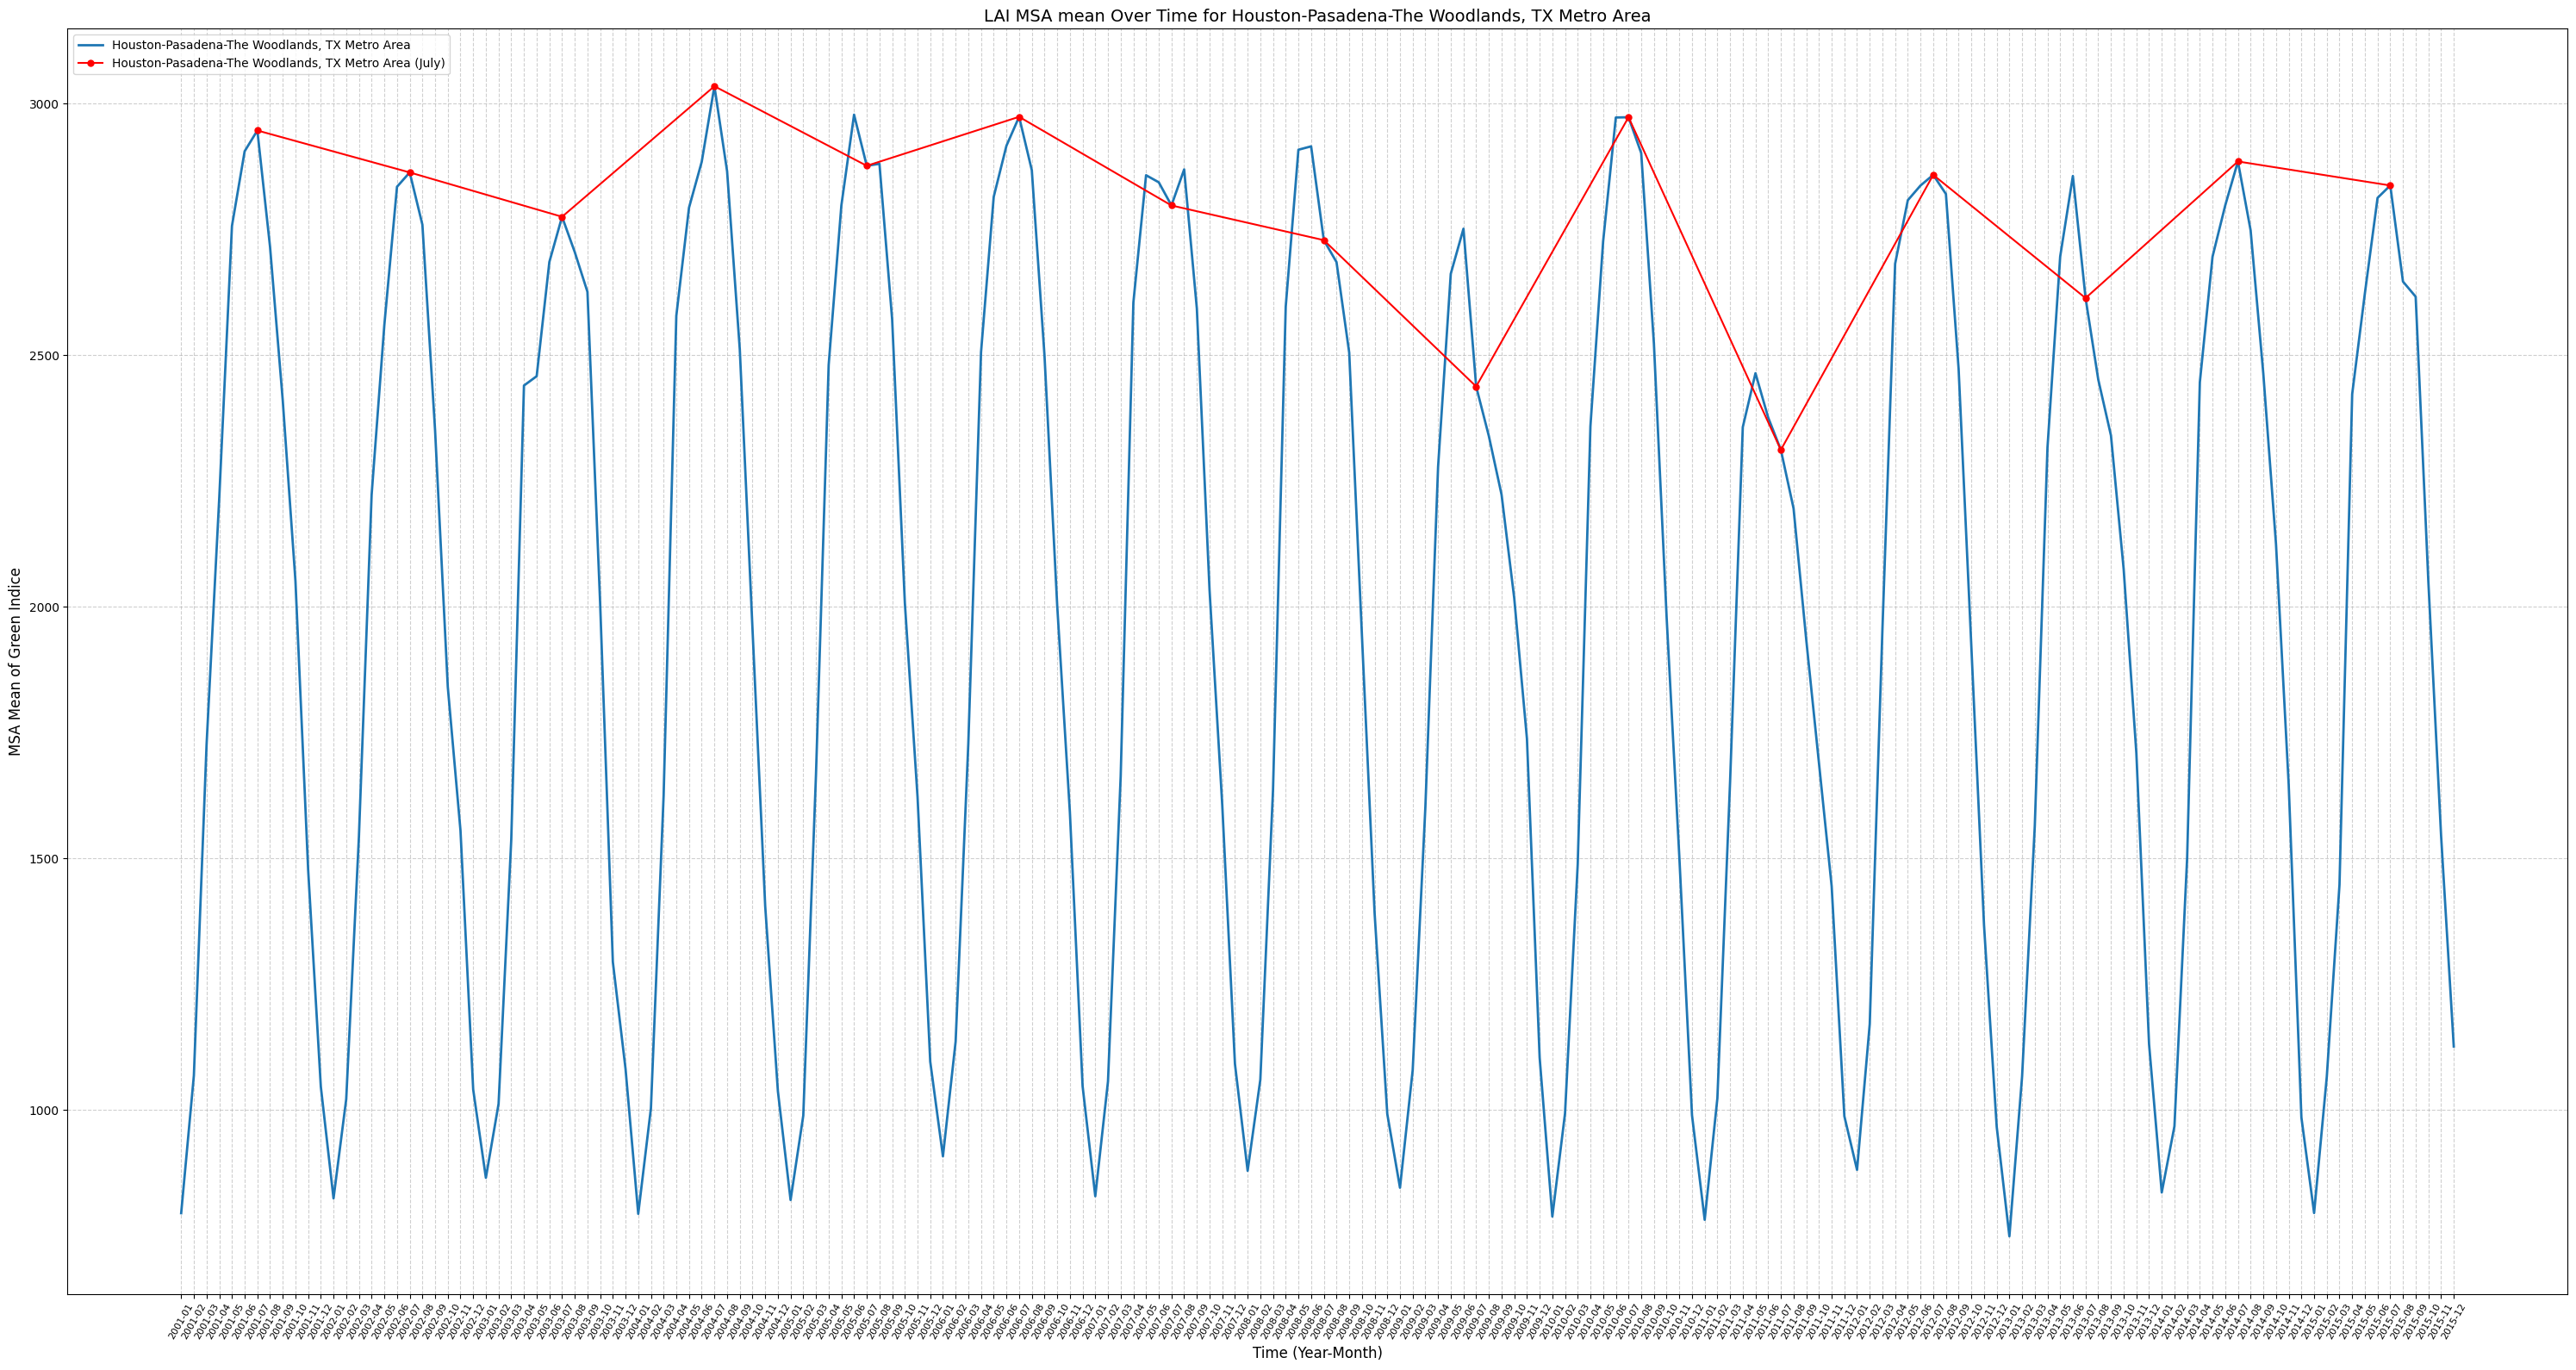

In [12]:


selected_MSA_list = [
    # 'Washington-Arlington-Alexandria, DC-VA-MD-WV Metro Area',
    # 'Pittsburgh, PA Metro Area',
    # 'New Orleans-Metairie, LA Metro Area',
    # 'Seattle-Tacoma-Bellevue, WA Metro Area',
    # 'Los Angeles-Long Beach-Anaheim, CA Metro Area',
    # 'Atlanta-Sandy Springs-Roswell, GA Metro Area',
    'Houston-Pasadena-The Woodlands, TX Metro Area'
    ]

for msa_name in selected_MSA_list:
    selected_msa = msa_gdf_crs4326[msa_gdf_crs4326['NAMELSAD'] == msa_name]
    time_series = []
    indice_mean_list = []
    july_time_series = []
    july_mean_list = []

    plt.figure(figsize=(30, 16))

    for year in range(2001, 2016):
        for month in range(1, 13):
            year_month = f'{year:04d}-{month:02d}'
            LAI_file = f'../gis/LAI/GIMMS_LAI4g_V1.2_{year:4d}{month:02d}01.tif' # only get the first half month for testing
            raster_ds = rxr.open_rasterio(LAI_file)  # Load with rioxarray
            
            # Convert raster data to a NumPy array
            raster_data = raster_ds.values[0]

            # Replace nodata (fill value) 65535 with NaN
            raster_data = np.where(raster_data == 65535, np.nan, raster_data)

            lai_selected_msa = get_masked_raster(selected_msa, raster_data, raster_ds.rio.transform())
            lai_selected_msa_mean = np.nanmean(lai_selected_msa)

            # print(lai_selected_msa_mean)
            time_series.append(year_month)
            indice_mean_list.append(lai_selected_msa_mean)
            if month == 7:
                july_time_series.append(year_month)
                july_mean_list.append(lai_selected_msa_mean)

    # print(time_series, indice_mean_list)
    
    # plot
    plt.plot(time_series, indice_mean_list, label=msa_name, linewidth=2)
    plt.plot(july_time_series, july_mean_list, 'ro-', label=f"{msa_name} (July)", markersize=5, linewidth=1.5) # july plot
        
    # plot the change of green indice over time
    plt.xlabel("Time (Year-Month)", fontsize=12)
    plt.ylabel("MSA Mean of Green Indice", fontsize=12)
    plt.title(f"LAI MSA mean Over Time for {msa_name}", fontsize=14)
    plt.legend(loc="upper left", fontsize=10)
    plt.xticks(rotation=60, fontsize=8)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()

    plt.savefig(f'../figures/green_indices_explore/LAI_mean_over_time,{msa_name}.png', dpi=300, bbox_inches='tight')
    # plt.show()

### SIF

In [13]:
# Decompress the SIF files
import gzip
import shutil

for year in range(2001, 2016):
    for month in range(1, 13):
        SIF_file = f'../gis/SIF/GOSIF_{year:04d}.M{month:02d}.tif.gz'
        decompressed_file = SIF_file.replace('.gz', '')
        with gzip.open(SIF_file, 'rb') as f_in:
            with open(decompressed_file, 'wb') as f_out:
                shutil.copyfileobj(f_in, f_out)

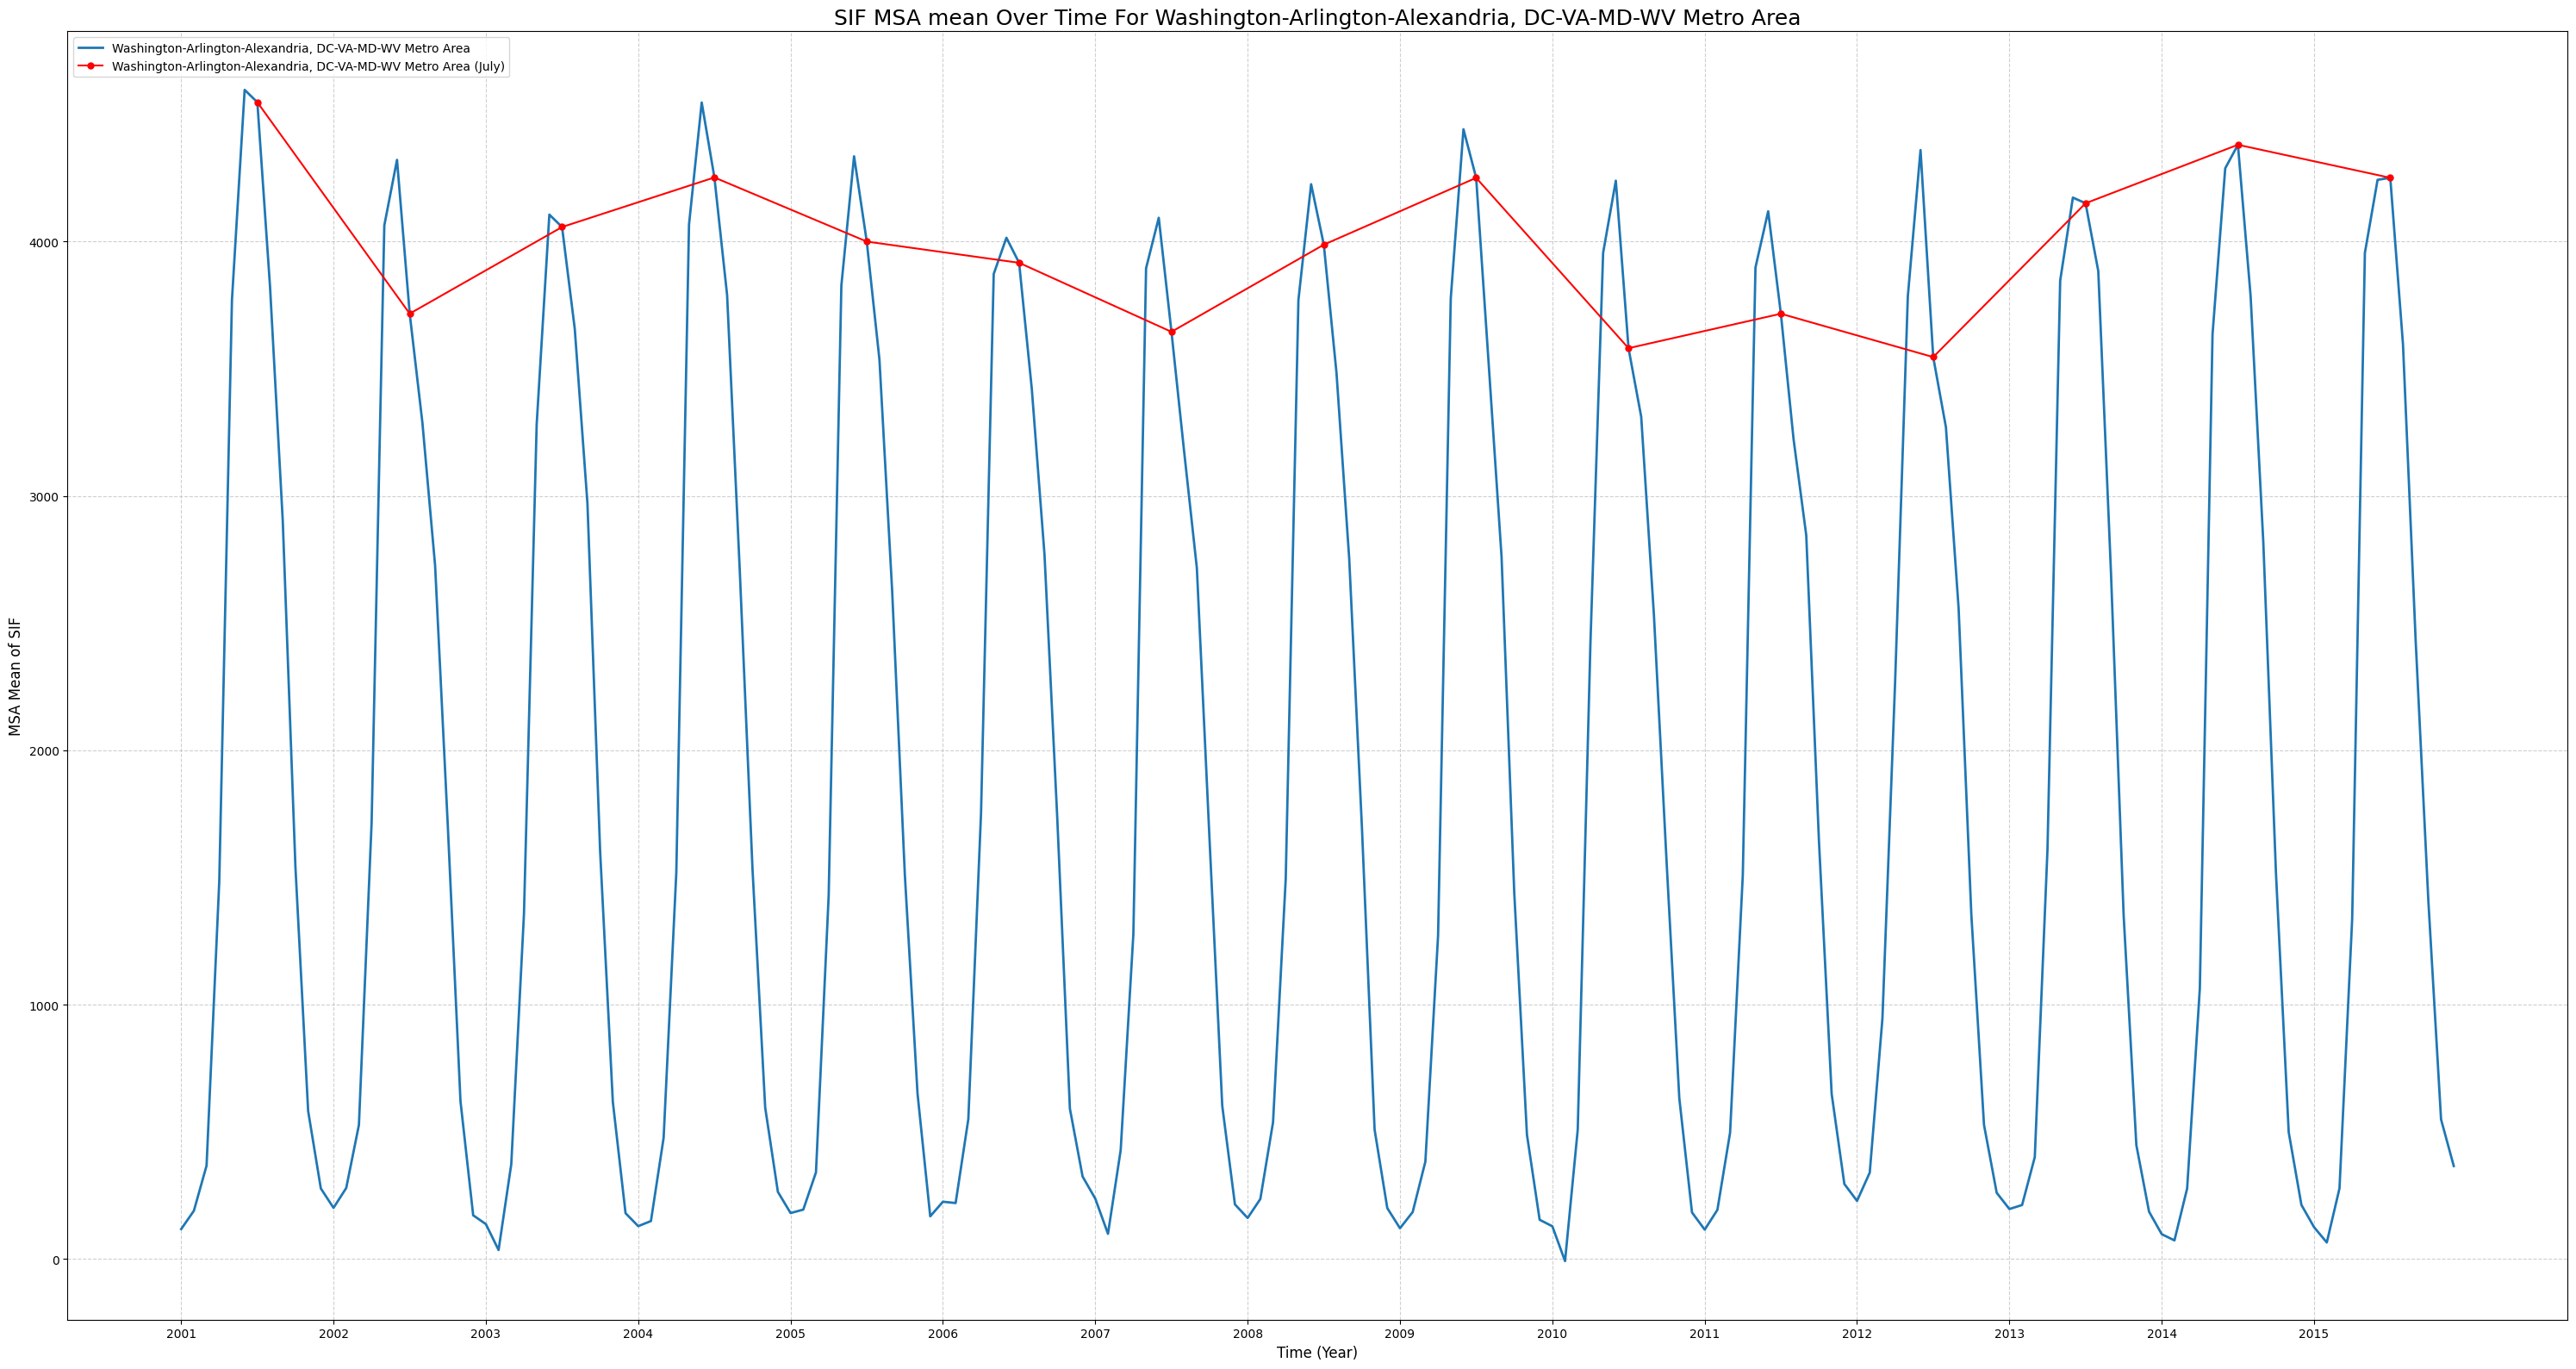

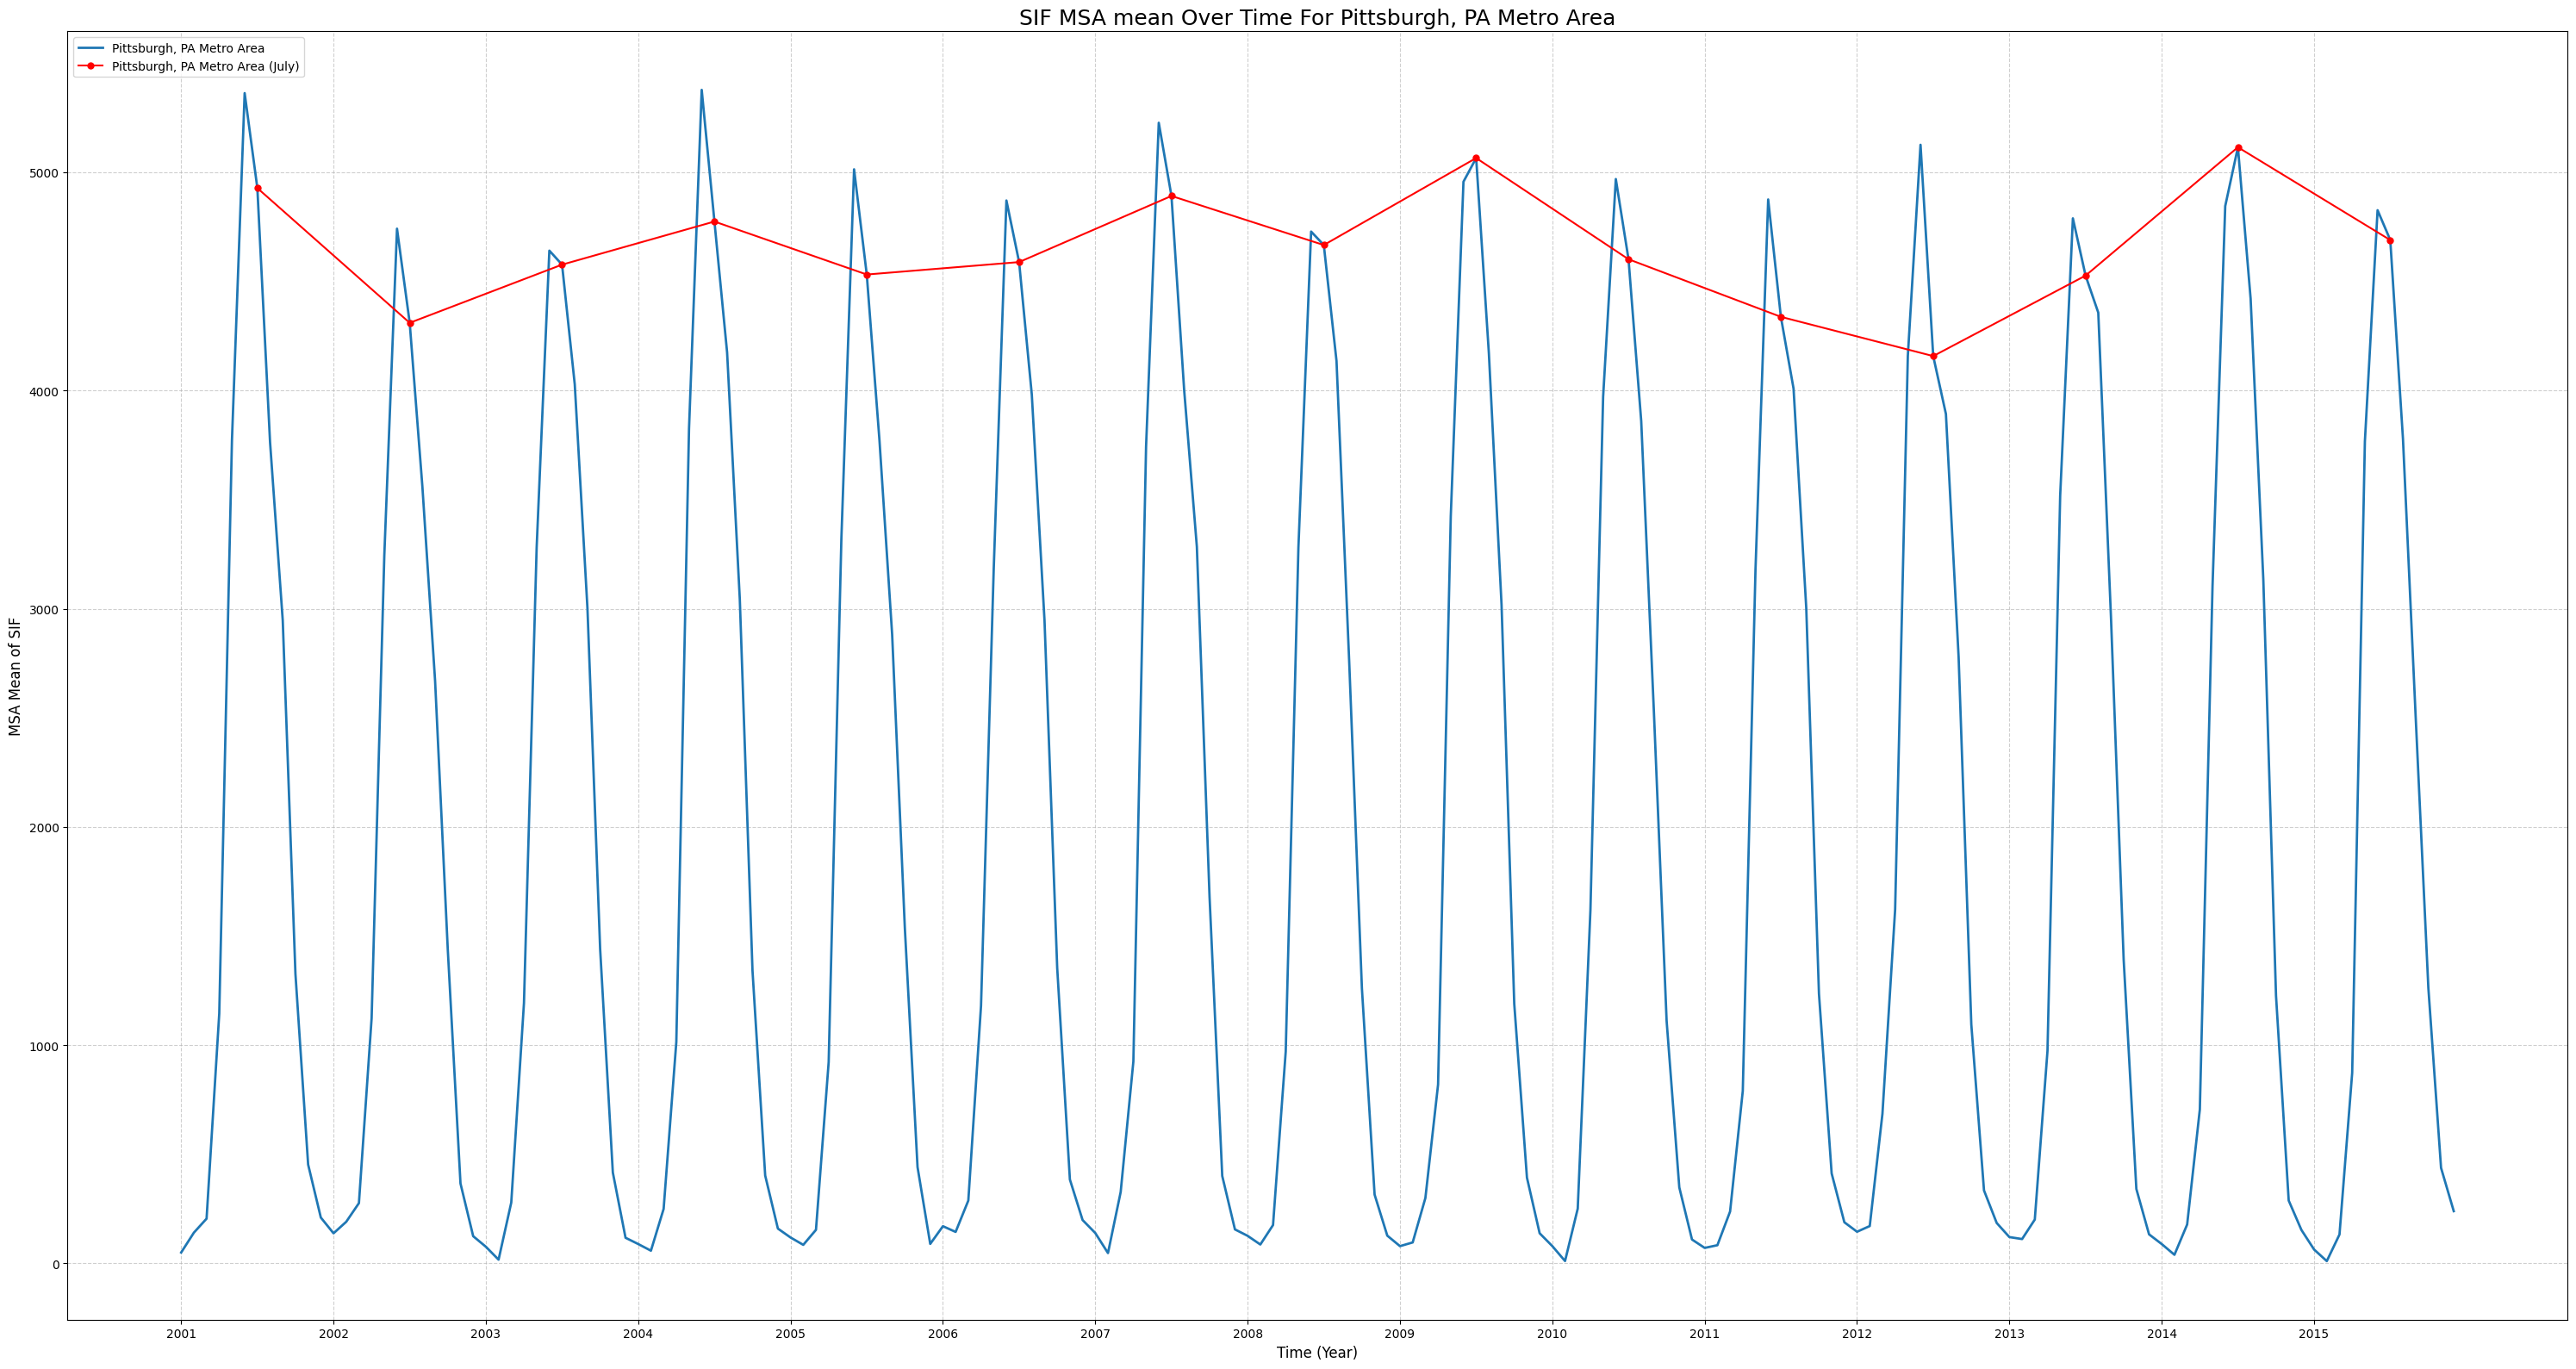

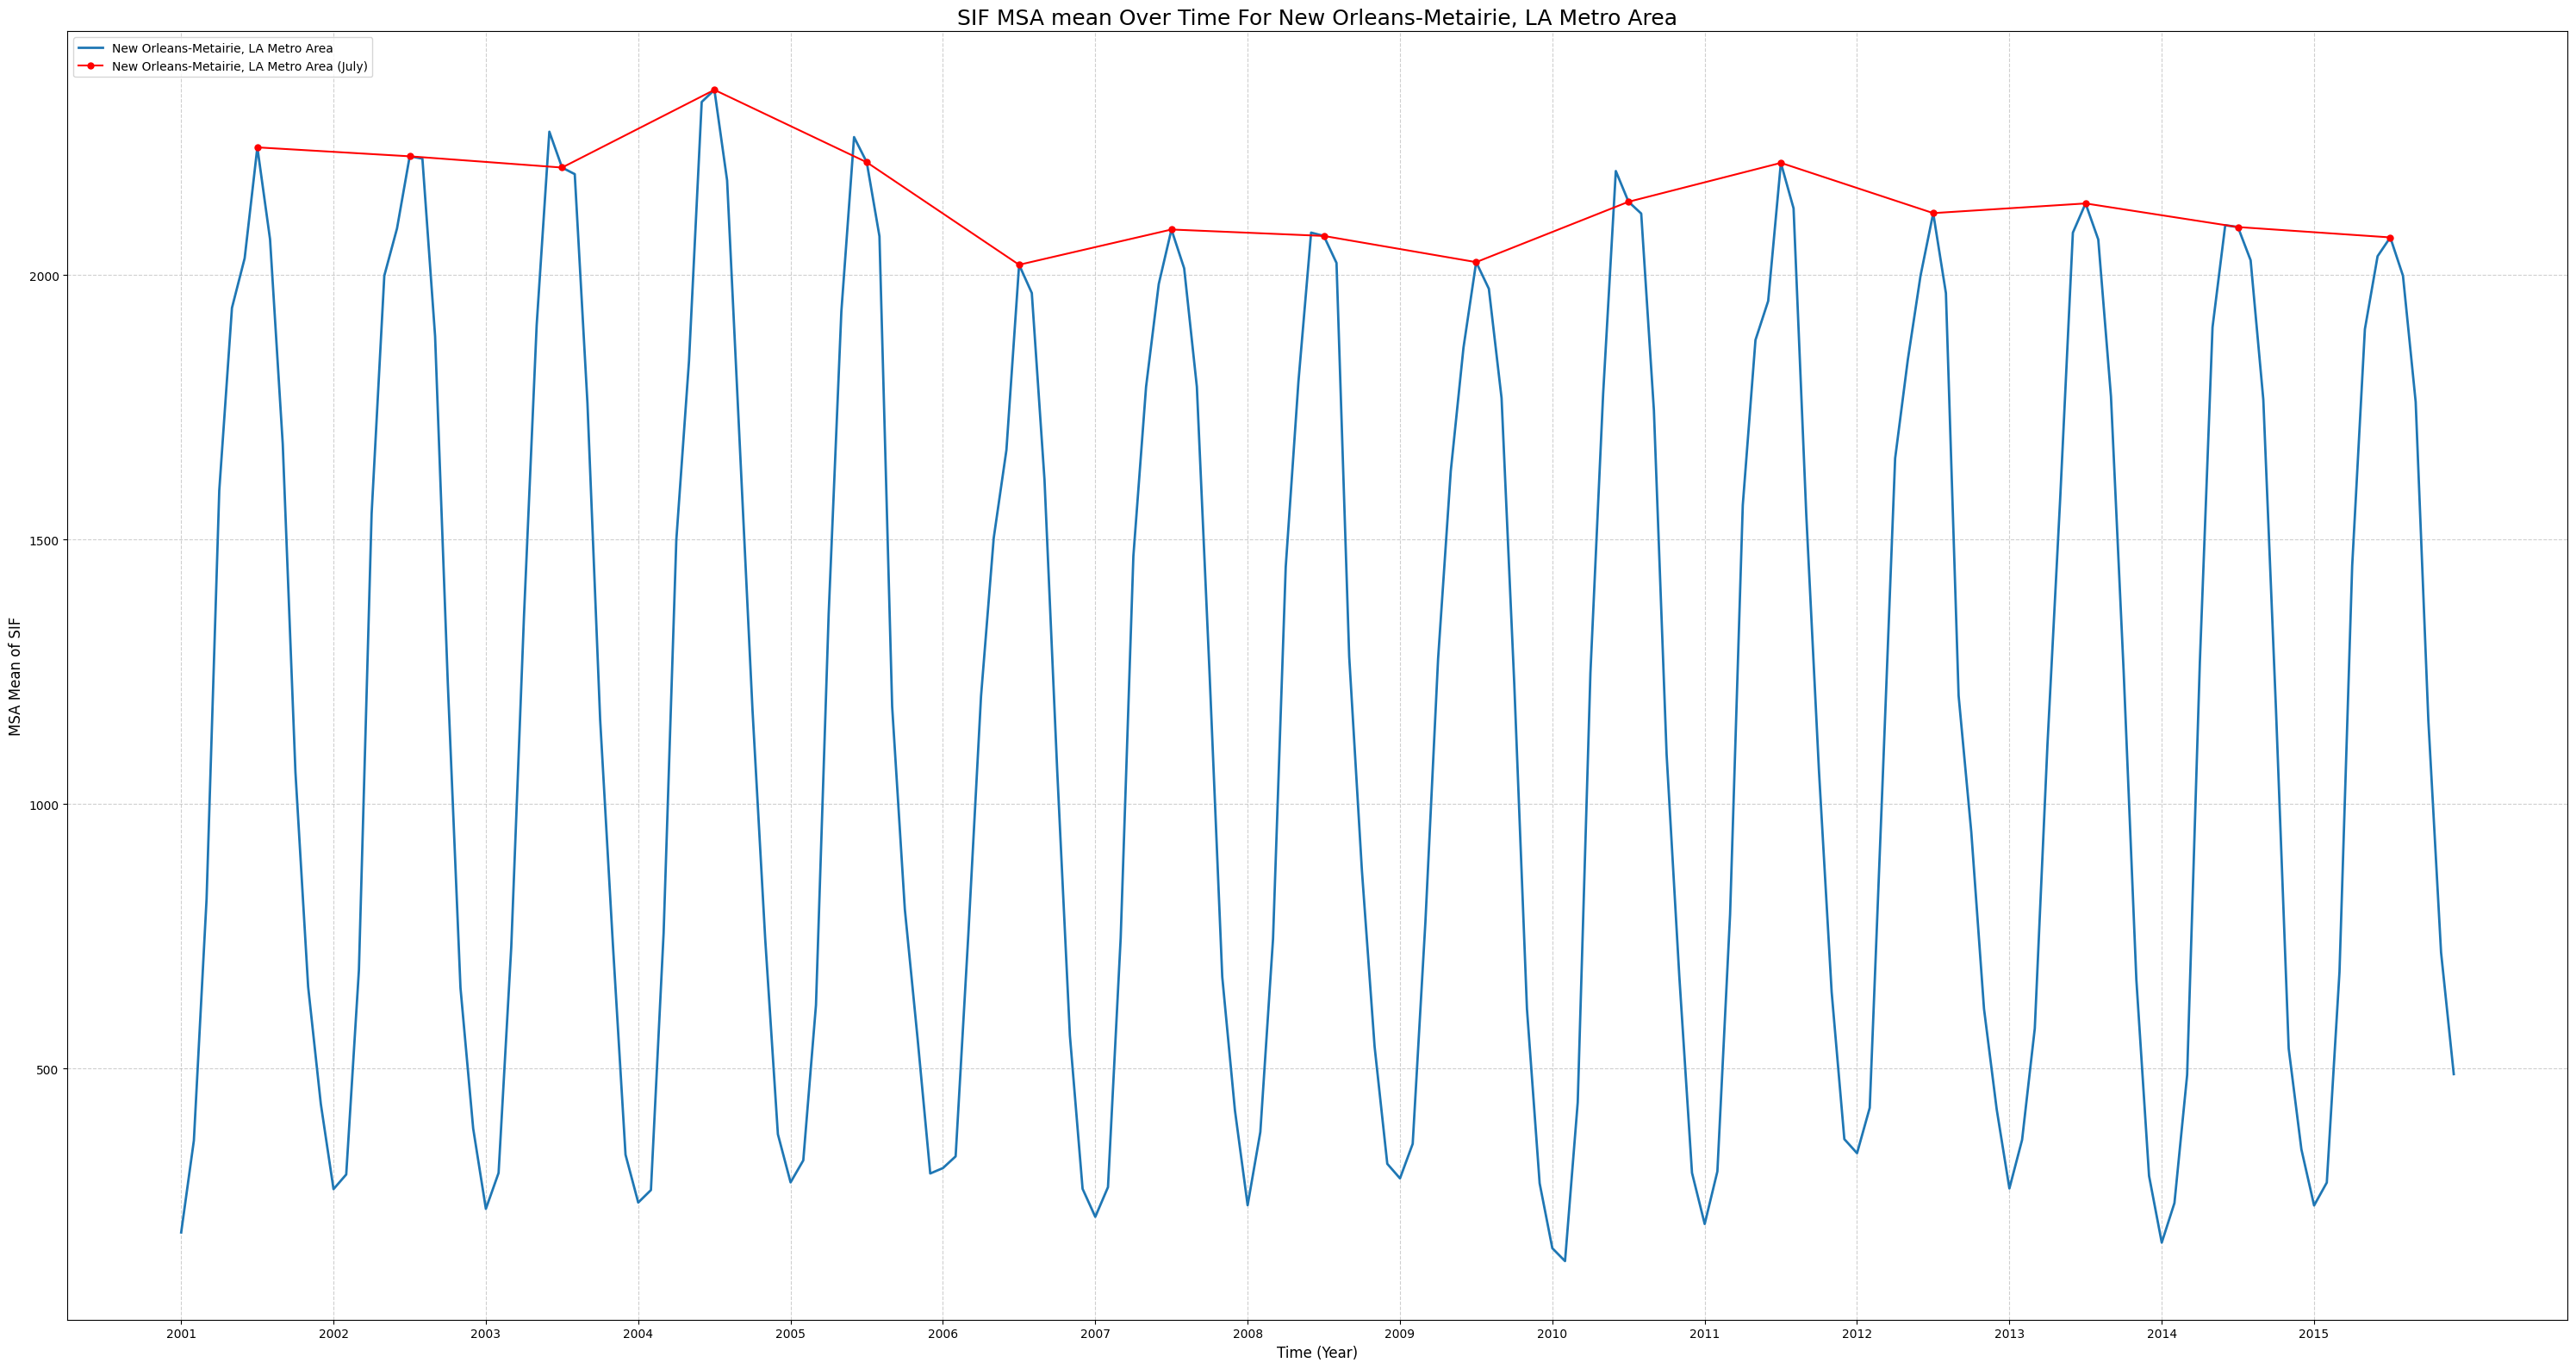

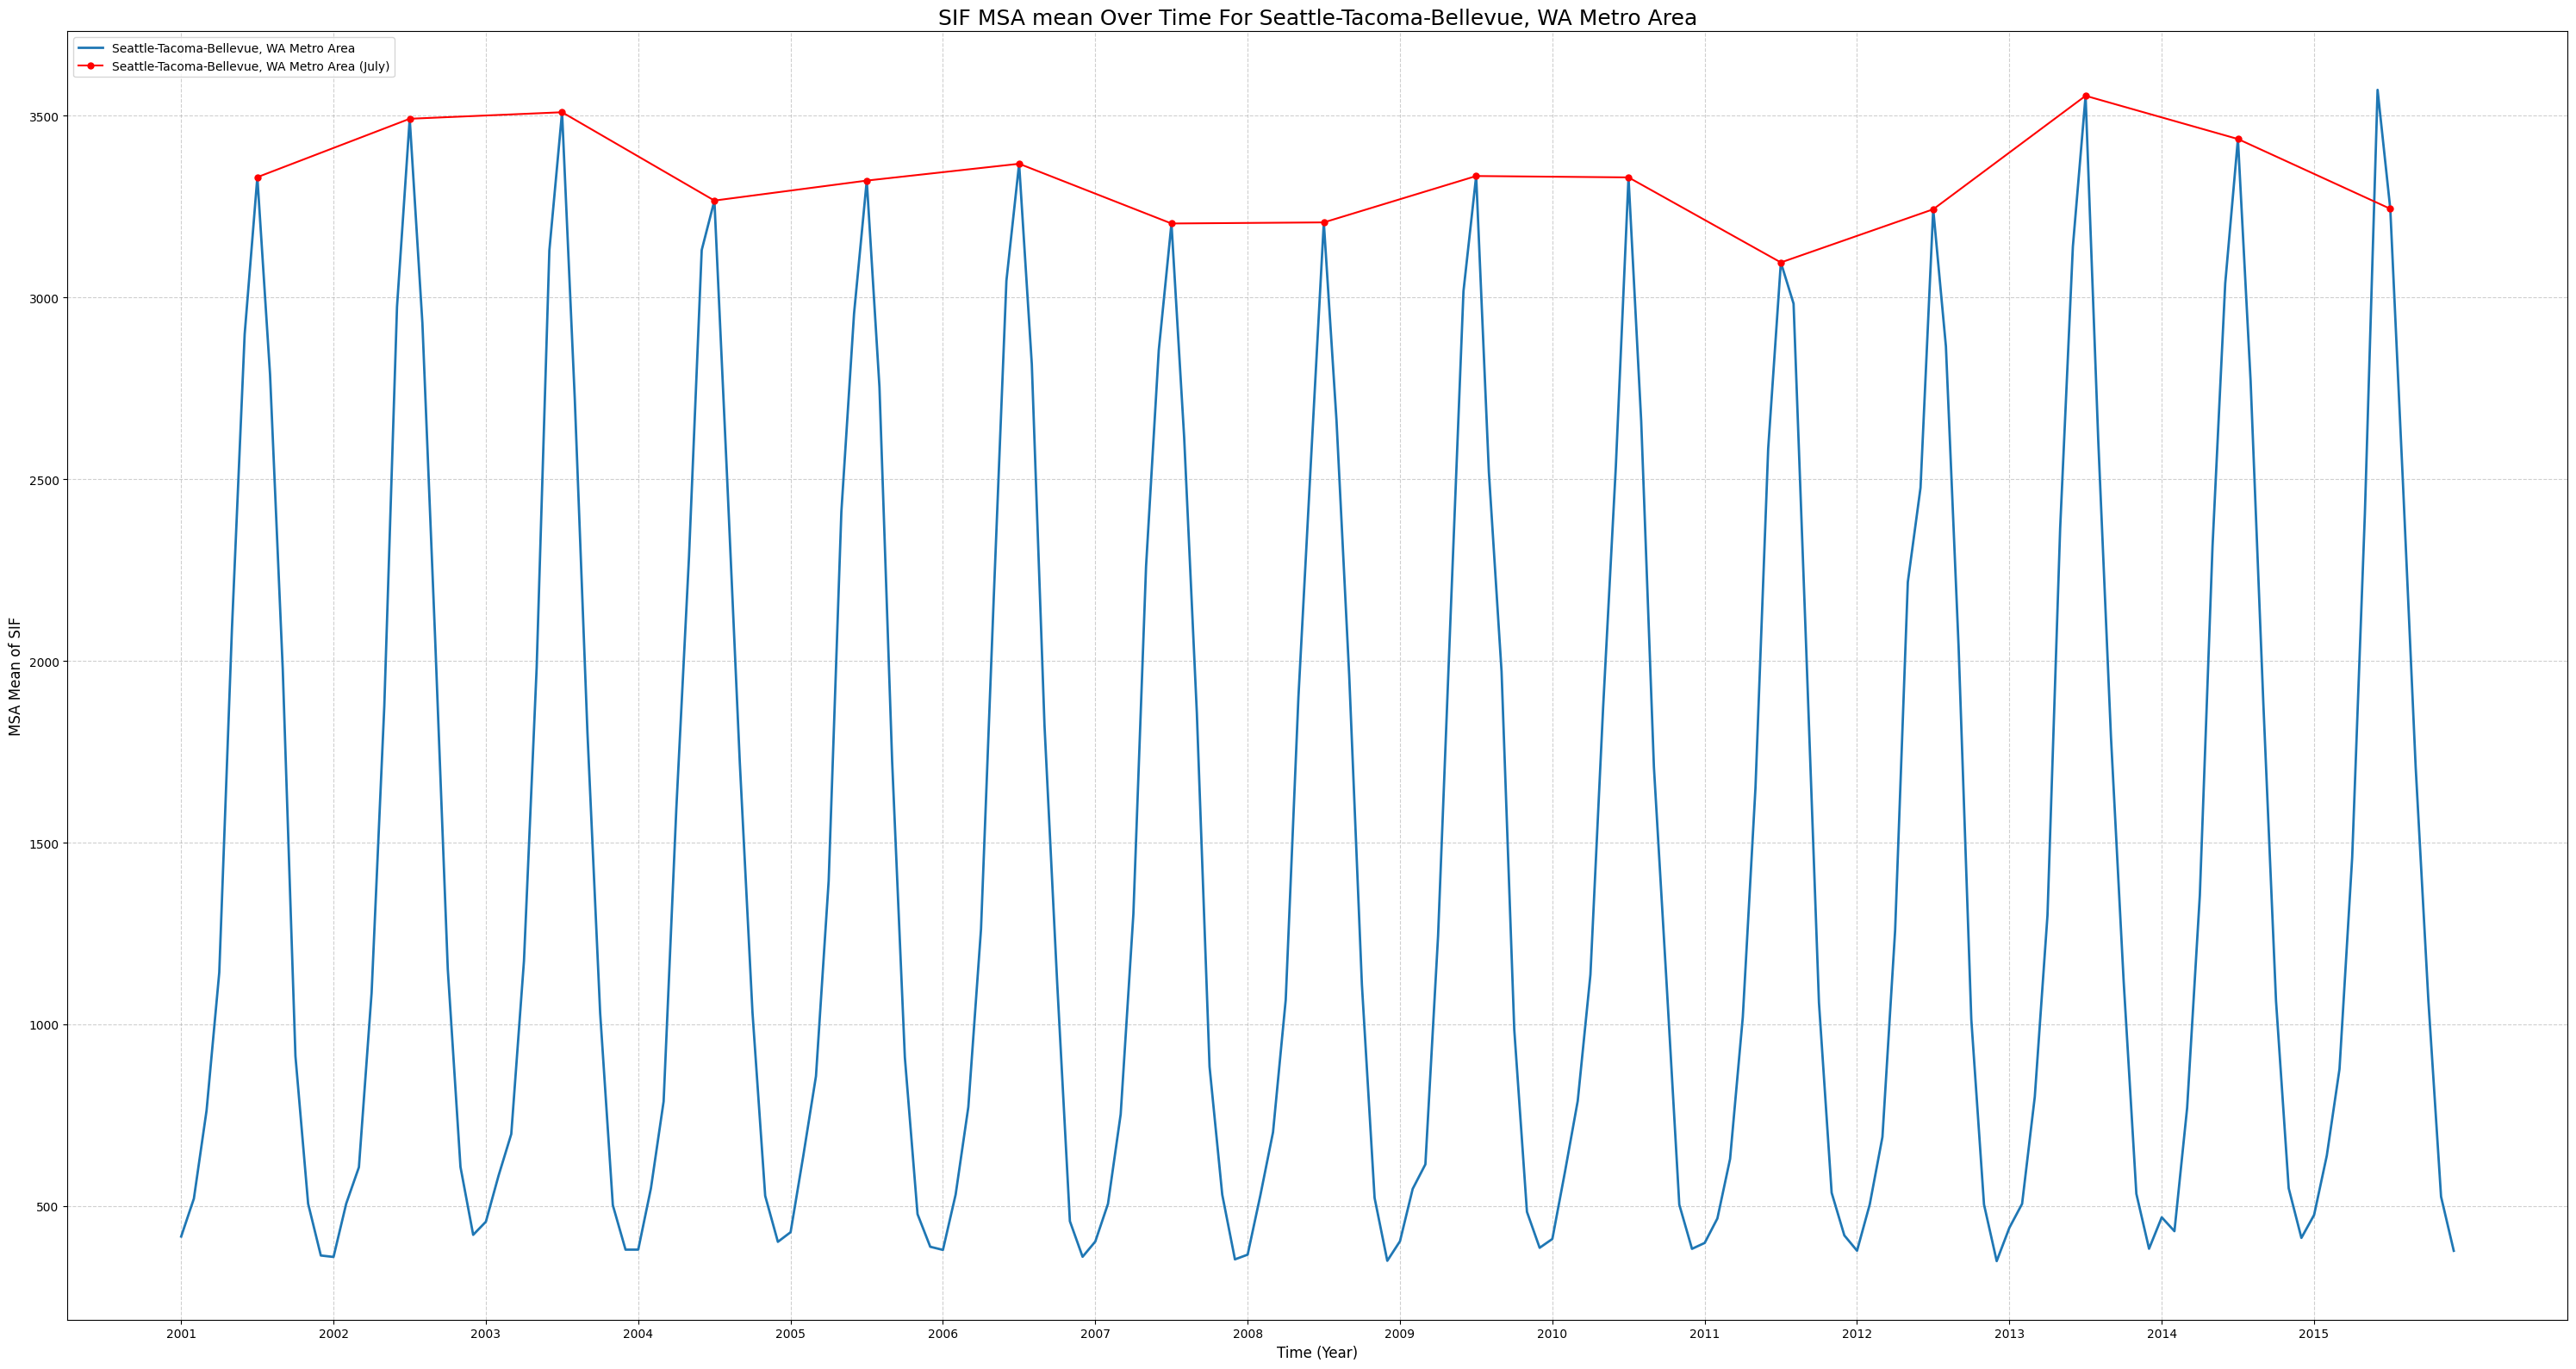

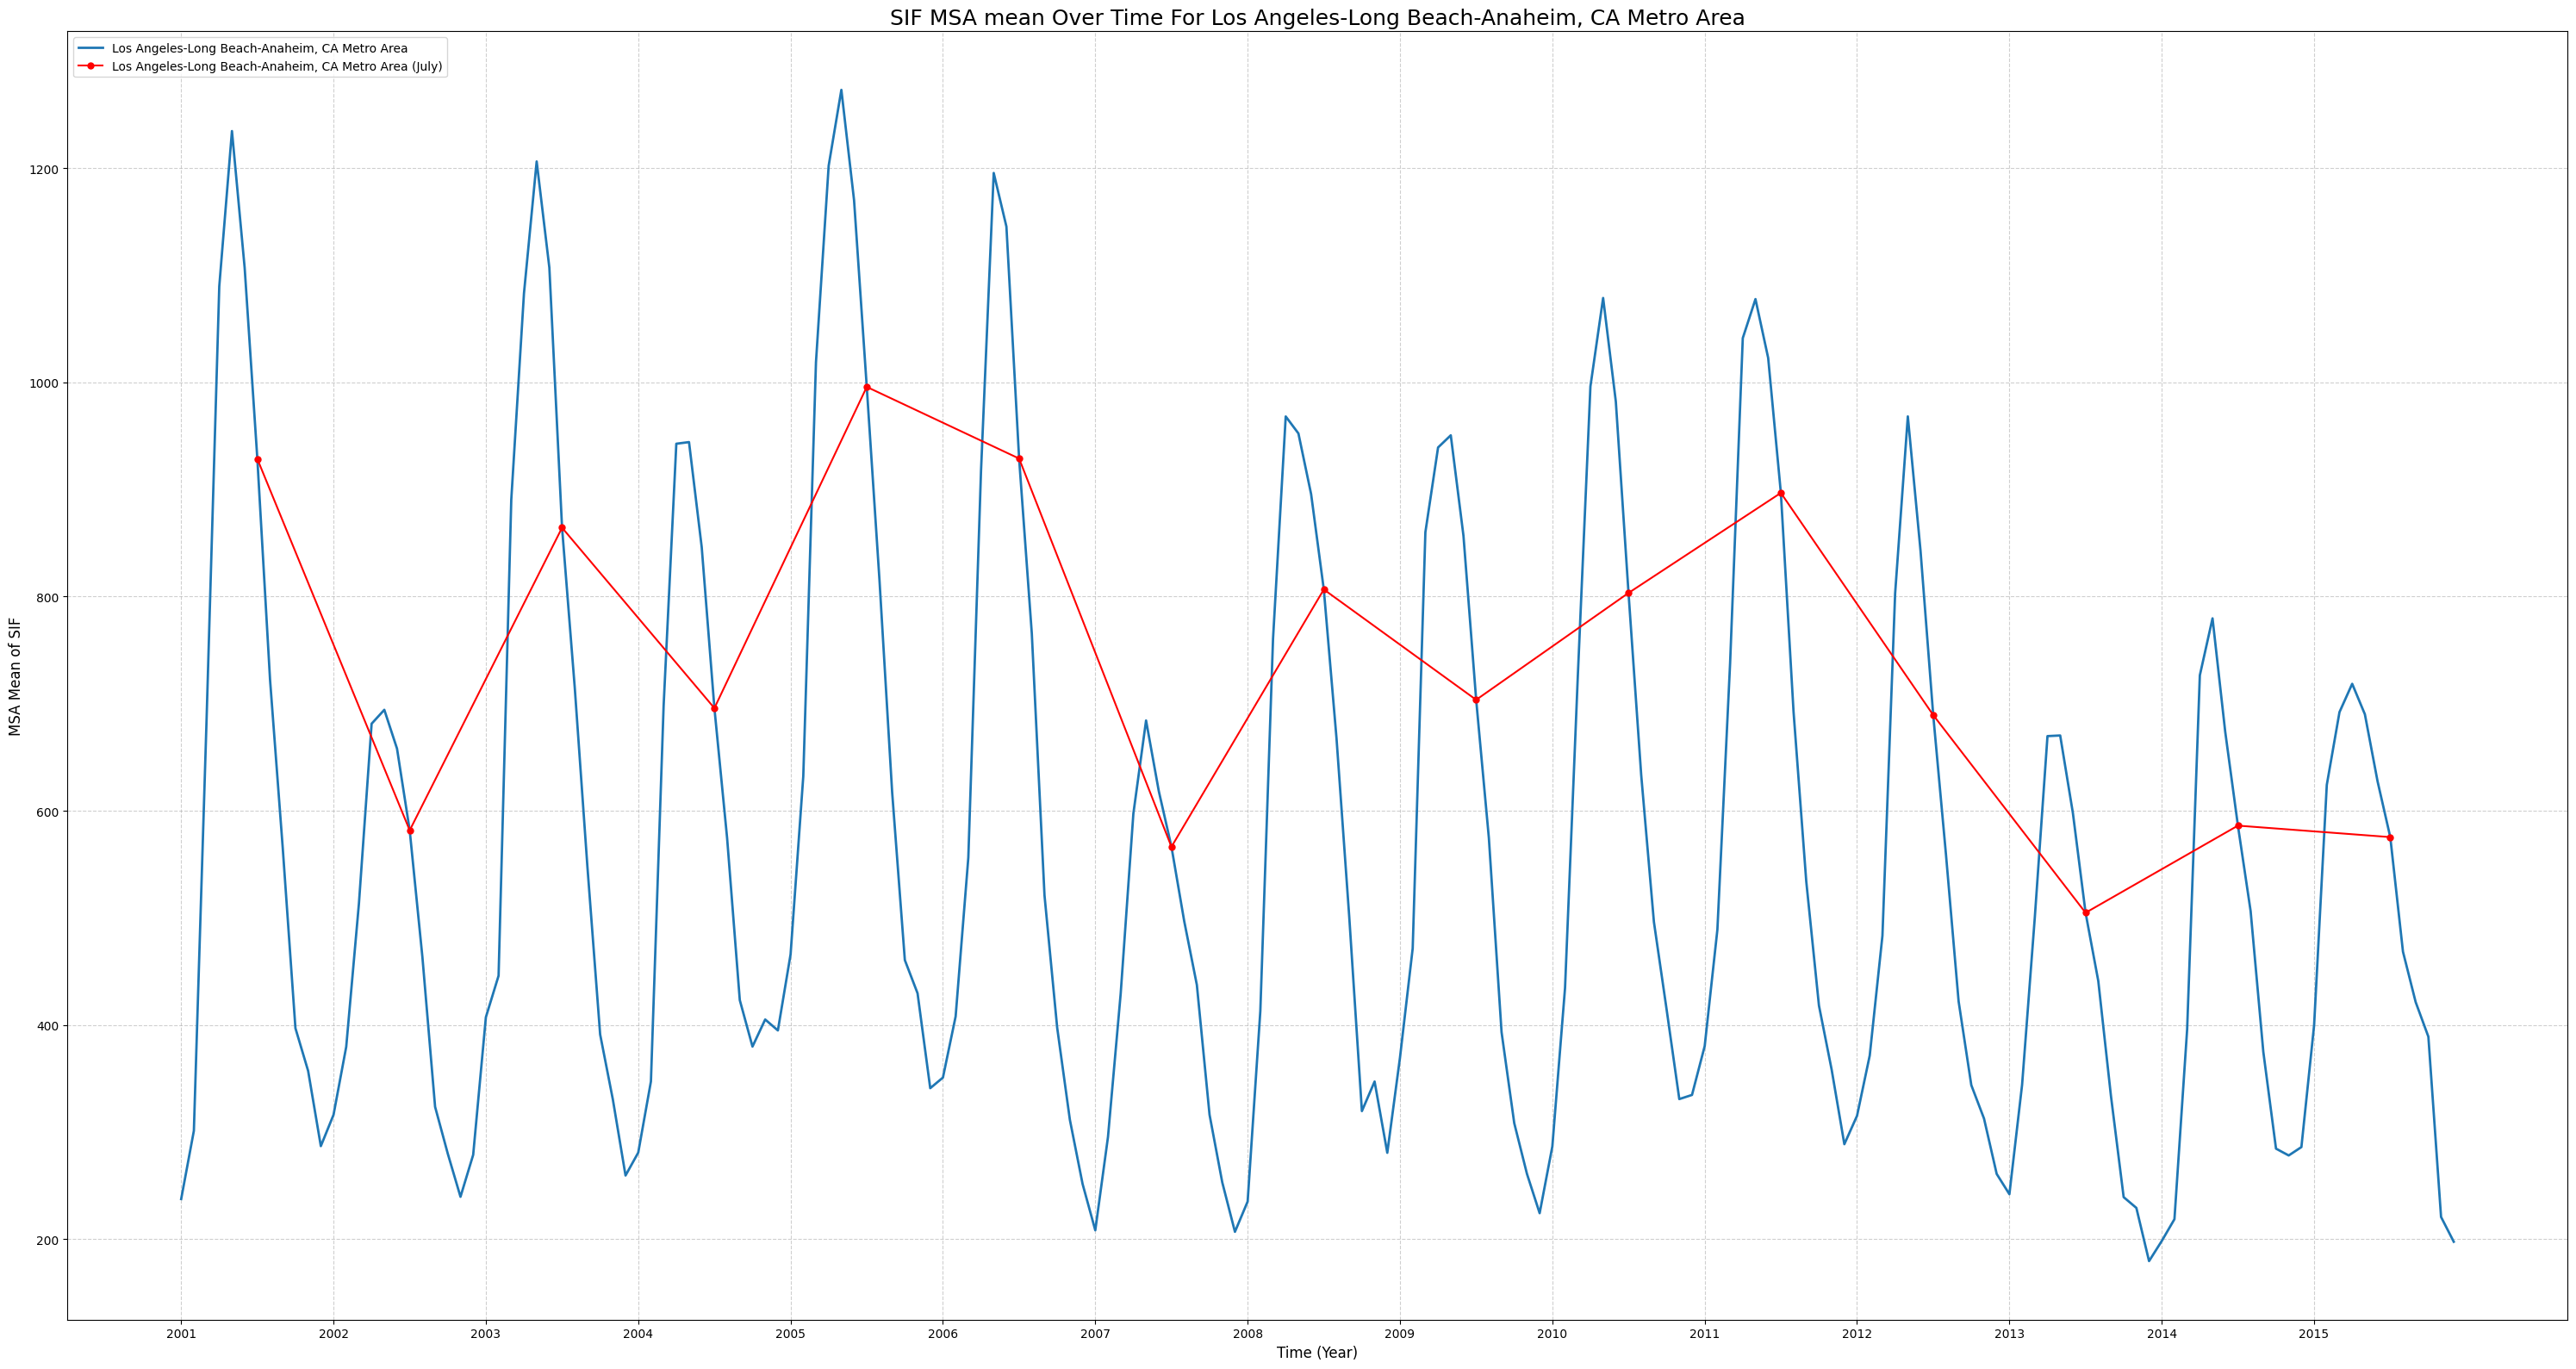

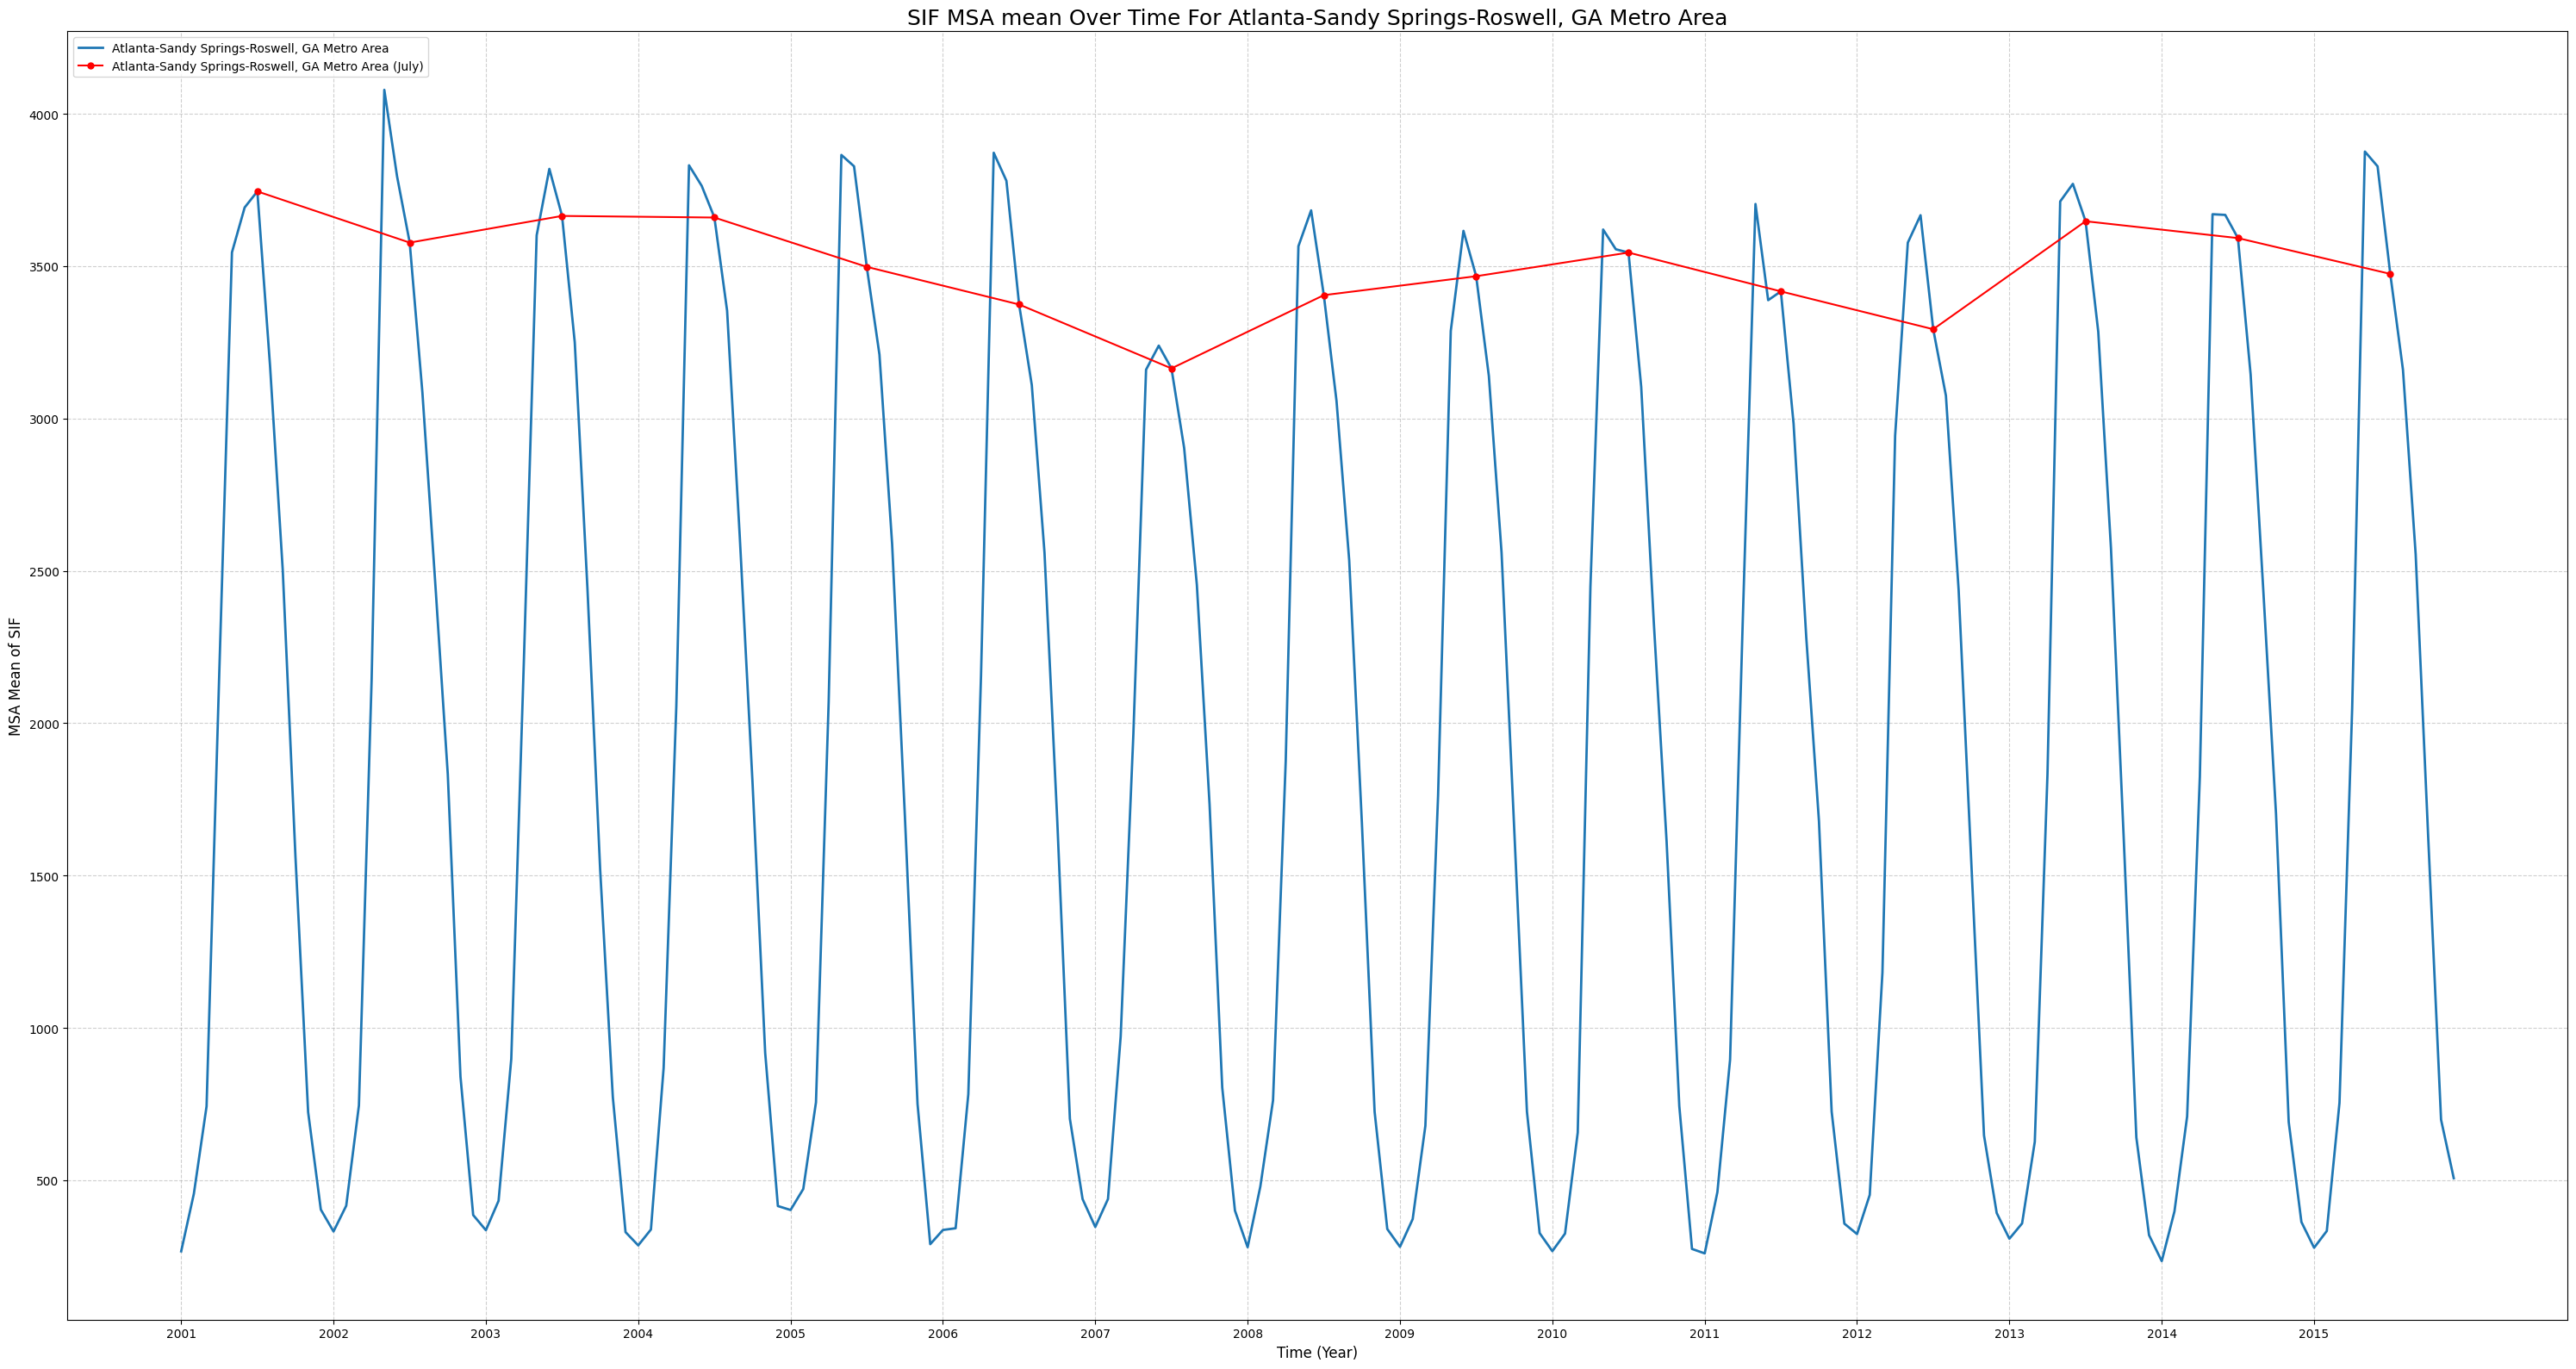

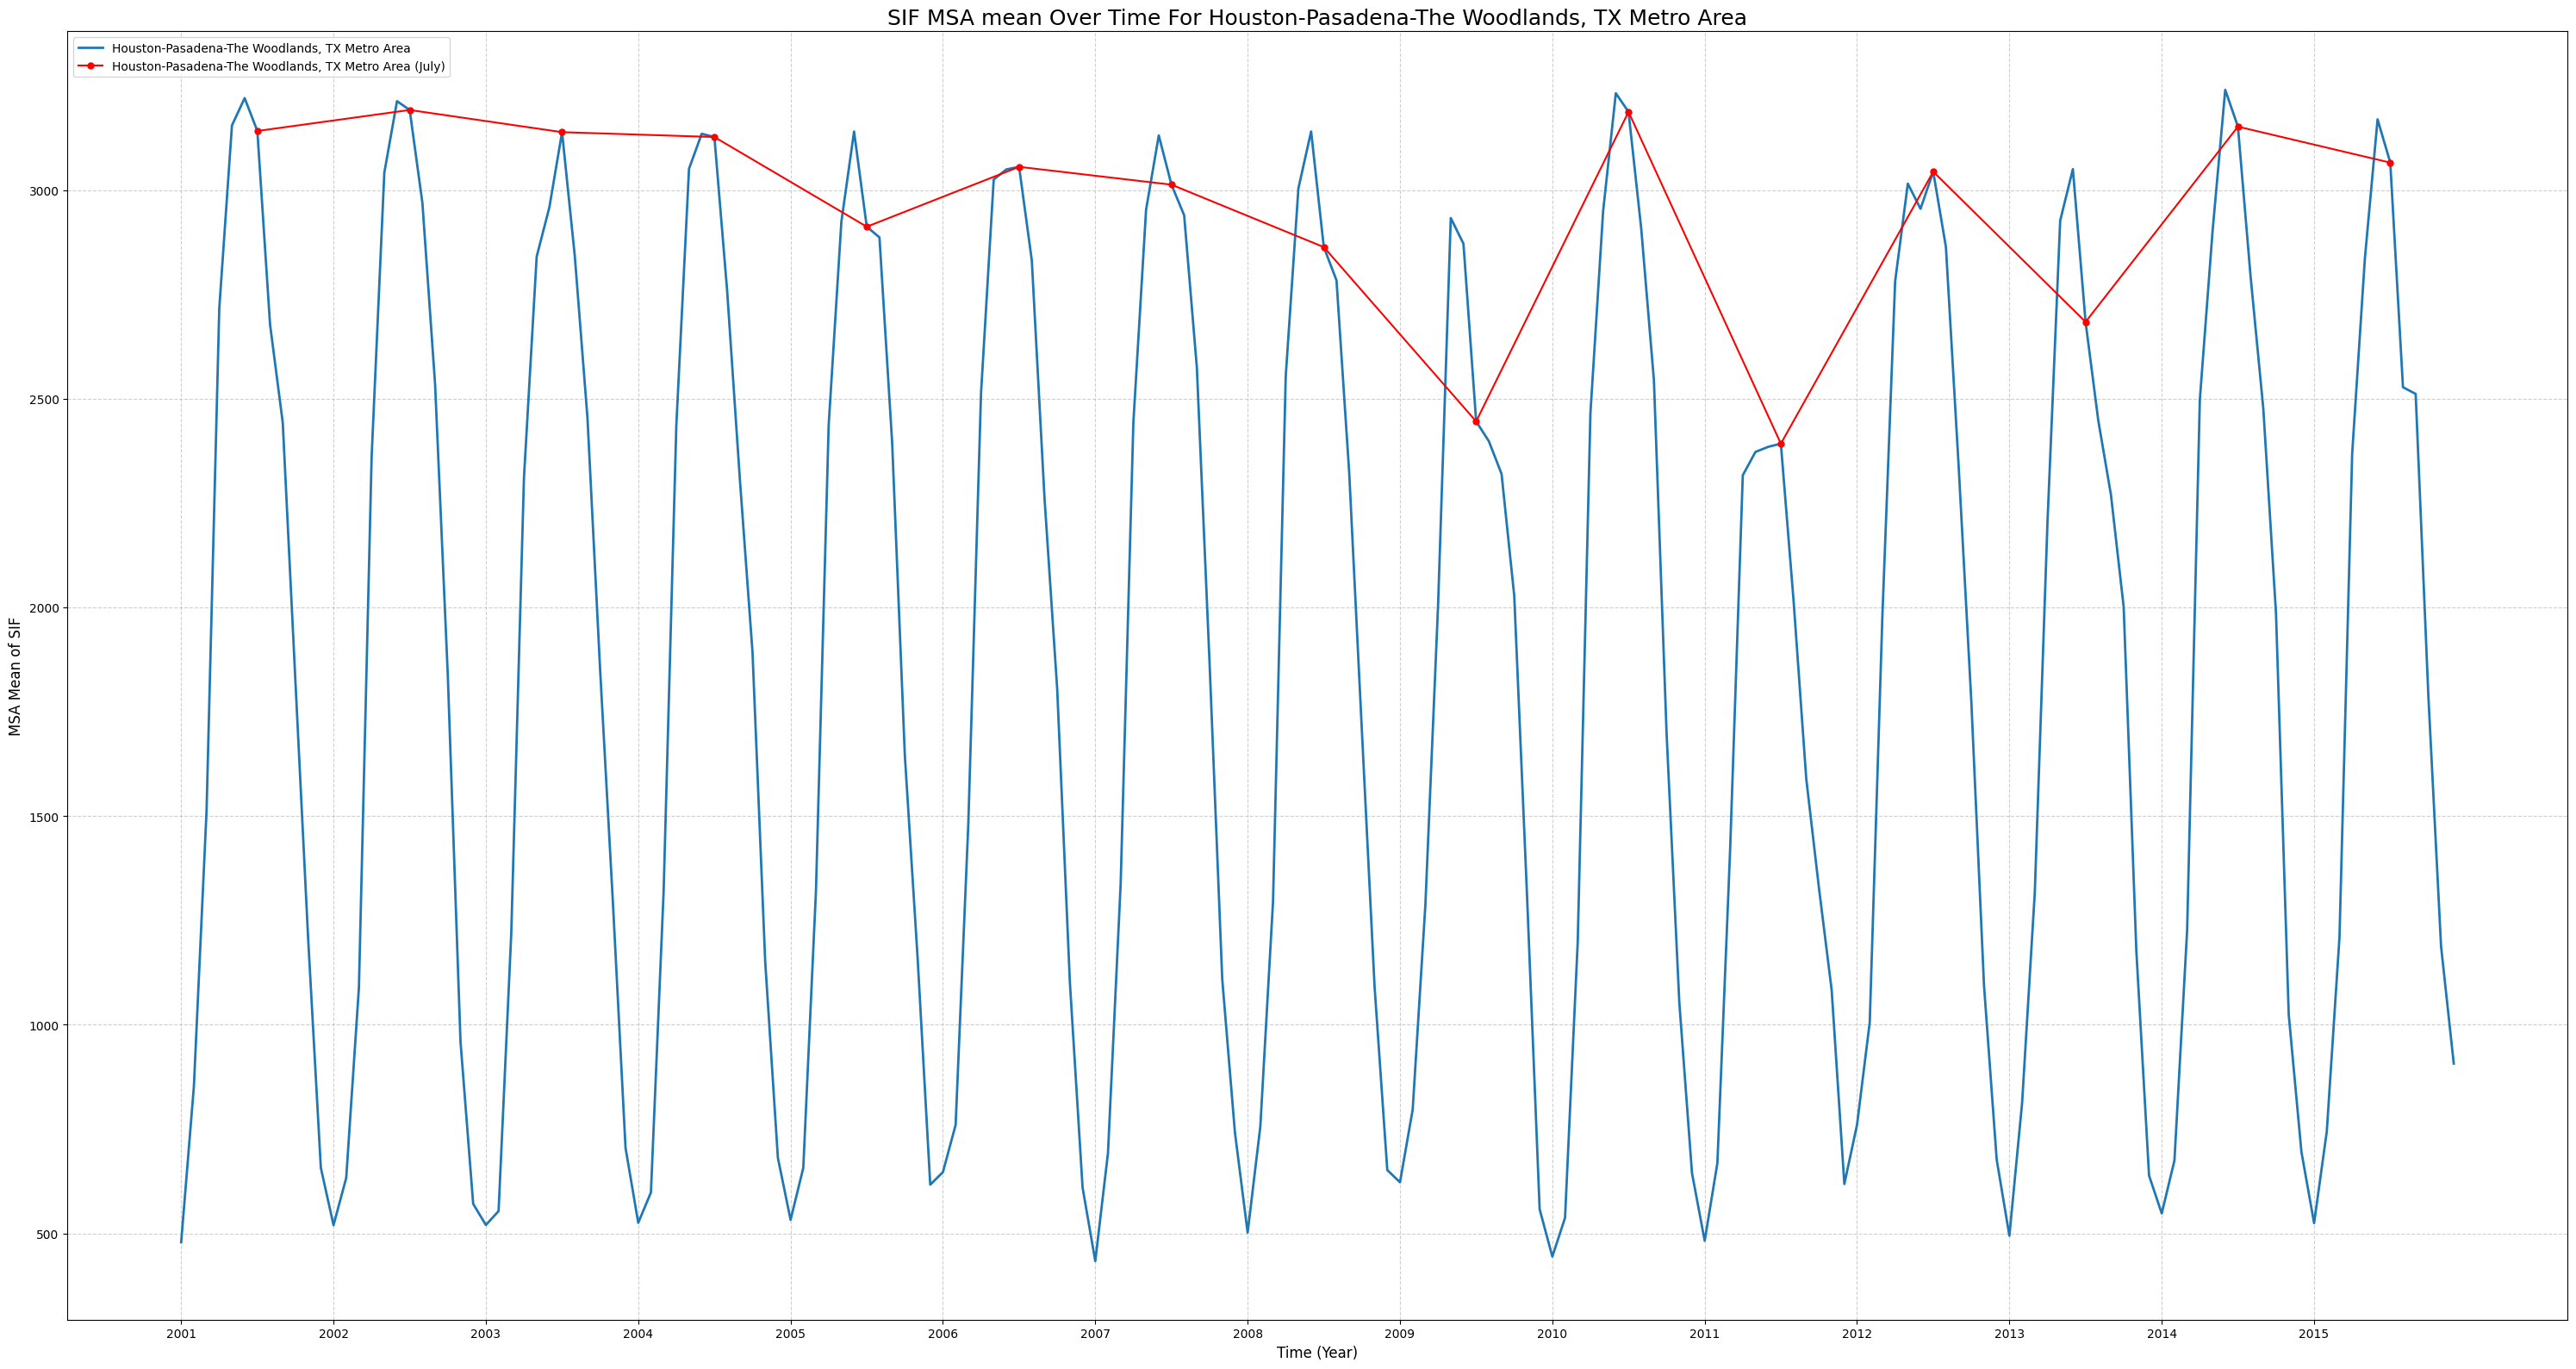

In [27]:
selected_MSA_list = [
    'Washington-Arlington-Alexandria, DC-VA-MD-WV Metro Area',
    'Pittsburgh, PA Metro Area',
    'New Orleans-Metairie, LA Metro Area',
    'Seattle-Tacoma-Bellevue, WA Metro Area',
    'Los Angeles-Long Beach-Anaheim, CA Metro Area',
    'Atlanta-Sandy Springs-Roswell, GA Metro Area',
    'Houston-Pasadena-The Woodlands, TX Metro Area'
    ]
for msa_name in selected_MSA_list:
    selected_msa = msa_gdf_crs4326[msa_gdf_crs4326['NAMELSAD'] == msa_name]
    time_series = []
    indice_mean_list = []
    july_time_series = []
    july_mean_list = []

    plt.figure(figsize=(30, 16))

    for year in range(2001, 2016):
        for month in range(1, 13):
            year_month = f'{year:04d}-{month:02d}'
            SIF_file = f'../gis/SIF/GOSIF_{year:04d}.M{month:02d}.tif'
            raster_ds = rxr.open_rasterio(SIF_file)  # Load with rioxarray
            
            # Convert raster data to a NumPy array
            raster_data = raster_ds.values[0]

            # Replace nodata (fill value) 32767 with NaN
            raster_data = np.where(raster_data == 32767, np.nan, raster_data)

            sif_selected_msa = get_masked_raster(selected_msa, raster_data, raster_ds.rio.transform())
            sif_selected_msa_mean = np.nanmean(sif_selected_msa)

            time_series.append(year_month)
            indice_mean_list.append(sif_selected_msa_mean)
            if month == 7:
                july_time_series.append(year_month)
                july_mean_list.append(sif_selected_msa_mean)

    # print(time_series, indice_mean_list)
    
    # plot
    plt.plot(time_series, indice_mean_list, label=msa_name, linewidth=2)
    plt.plot(july_time_series, july_mean_list, 'ro-', label=f"{msa_name} (July)", markersize=5, linewidth=1.5) # july plot
        
    # plot the change of green indice over time
    # Select labels only for January of each year
    selected_ticks = time_series[::12]  # Pick every January
    selected_labels = [t[:4] for t in selected_ticks]  # Extract only the year
    plt.xticks(selected_ticks, selected_labels, fontsize=10)
    
    plt.xlabel("Time (Year)", fontsize=12)
    plt.ylabel("MSA Mean of SIF", fontsize=12)
    plt.title(f"SIF MSA mean Over Time For {msa_name}", fontsize=18)
    plt.legend(loc="upper left", fontsize=10)

    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()

    plt.savefig(f'../figures/green_indices_explore/SIF_mean_over_time,{msa_name}.png', dpi=300, bbox_inches='tight')


In [ ]:
xticks = dates[::12]  # Select only January of each year for ticks
xticklabels = [date.strftime("%Y") for date in xticks]  # Format as Year

# Apply ticks and labels
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)